<h3><center>Does having Ballon d'Or players increase a nation's chance of winning the World Cup,
or does winning the World Cup increase a player's chance of receiving Ballon d'Or votes?</center> </h3>

-----------------------------------------------------------------------------------------------------------------------

<li>Ballon d'Or & World Cup – Datenanalyse</li>

In [239]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from statsmodels.graphics.mosaicplot import mosaic

from scipy.stats import  mannwhitneyu
from scipy.stats import  fisher_exact

<li>Load data from csv files</li>


In [240]:
players = pd.read_csv("players.csv")
ballondor = pd.read_csv("ballondor_all_ranked.csv")
standing = pd.read_csv("tournament_standings_2.csv")
matches_players = pd.read_csv("player_appearances.csv")

<li>Show the first 10 entries of each tabel</li>

In [241]:
#players.head()


In [242]:
#ballondor_combined.head()

In [243]:
#standing.head()

In [244]:
#matches_players.head()

<ol>
<li>Filter for Men's worldcup due to tabel containing Womens worldcup as well</li>
<li>Filter out the woldcup years</li>
<li>Converting "Years" of the ballondor set into an integer</li>
</ol>
<br>
<li>Print out the Number of Wolrdcups considerd in this analysis</li>

In [245]:

wc_standings = standing[standing["tournament_name"].str.contains("FIFA Men's World Cup", case=False, na=False)].copy()
wc_matches_players = matches_players[matches_players["tournament_name"].str.contains("FIFA Men's World Cup", case=False, na=False)].copy()

wc_standings["year"] = wc_standings["tournament_name"].str.extract(r"(\d{4})").astype(int)
wc_matches_players["year"] = wc_matches_players["tournament_name"].str.extract(r"(\d{4})").astype(int)

ballondor["Year"] = ballondor["Year"].astype(int)

print(f"Number of World Cups we consider: ")
print((len(wc_standings)/4))


Number of World Cups we consider: 
14.0


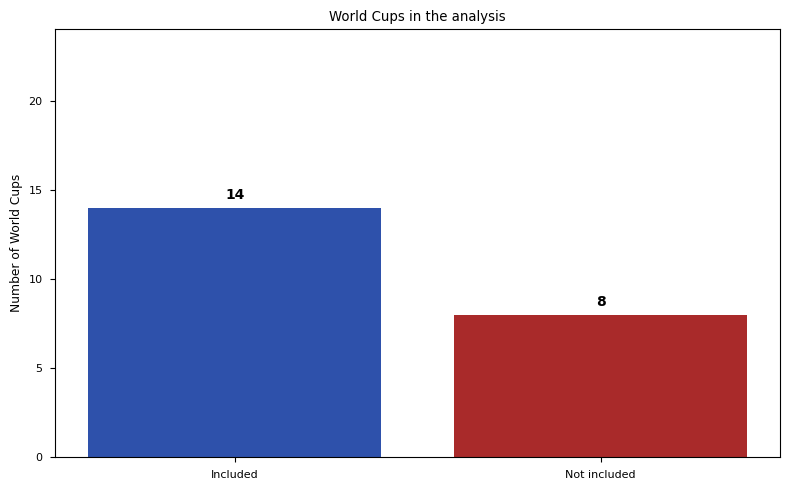

In [246]:
total_wcs = len(wc_standings) / 4  # 14
all_wcs_ever = 22  # total number of World Cups


fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(['Included', 'Not included'],
       [total_wcs, all_wcs_ever - total_wcs],
       color=["#2E51AB", "#A92A2A"])
ax.set_ylabel('Number of World Cups')
ax.set_title('World Cups in the analysis')
ax.set_ylim(0, all_wcs_ever + 2)  

for i, v in enumerate([total_wcs, all_wcs_ever - total_wcs]):
    ax.text(i, v + 0.5, str(int(v)), ha='center', fontweight='bold') 

plt.tight_layout()
plt.show()


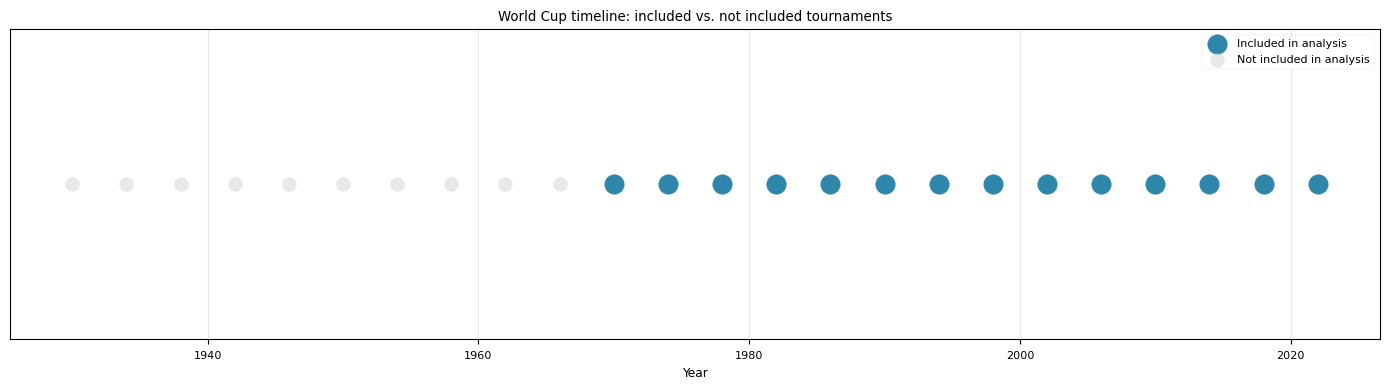

Years included in analysis: [1970, 1974, 1978, 1982, 1986, 1990, 1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022]
Number of World Cups considered in total: 14


In [247]:
unique_years = sorted(wc_standings["year"].unique())
all_wc_years = list(range(1930, 2023, 4)) #all world cups from 1930 to today in 4 year steps

fig, ax = plt.subplots(figsize=(14, 4))

#Included world cups
ax.scatter(
    unique_years,
    [1] * len(unique_years),
    s=200,
    c='#2E86AB',
    label='Included in analysis',
    zorder=3
) 

#Not included world cups
not_included_years = [y for y in all_wc_years if y not in unique_years]
ax.scatter(
    not_included_years,
    [1] * len(not_included_years),
    s=100,
    c='lightgray',
    label='Not included in analysis',
    alpha=0.5,
    zorder=2
)  
ax.set_yticks([])
ax.set_xlabel('Year')
ax.set_title('World Cup timeline: included vs. not included tournaments')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Years included in analysis: {[int(year) for year in unique_years]}")
print(f"Number of World Cups considered in total: {len(unique_years)}")

<li>Just printing the years of the cup with the amount of teams in the standing tabel (always 4 becaus standing.csv has 4 entries for each tournament)</li>

In [248]:
#wc_standings["year"].value_counts().sort_index()


<li>Unify the player names of both list wc_matches_players and ballondor. <br>
For wc_matches_player append both names together.</li>

In [249]:

wc_matches_players["player_fullname"] = (
    wc_matches_players["given_name"].fillna("") + " " + wc_matches_players["family_name"].fillna("")
).str.strip().str.lower()


ballondor["player_fullname"] = ballondor["Player"].str.strip().str.lower()


<li>Print the first 10 entries of both tabel colums "player_fullname"</li>

In [250]:
print(ballondor["player_fullname"].head(10))
print(wc_matches_players["player_fullname"].head(10))

0          gerd müller
1          bobby moore
2            gigi riva
3    franz beckenbauer
4     wolfgang overath
5        dragan dzajic
6         johan cryuff
7         gordon banks
8       sandro mazzola
9         rinus israel
Name: player_fullname, dtype: object
0         ignacio calderón
1             gustavo peña
2              mario pérez
3      guillermo hernández
4    horacio lópez salgado
5            josé vantolrá
6            javier guzmán
7            héctor pulido
8            mario velarde
9          javier valdivia
Name: player_fullname, dtype: object


<li>Check for duplicates</li>

In [251]:
wc_matches_players["player_fullname"].nunique(), len(wc_matches_players)

(5079, 20618)

In [252]:
ballondor["player_fullname"].nunique(), len(ballondor)

(389, 810)

<li>Get rid of duplicates and make every entry for player in tournament unique.<br>
<u>Important:</u> One player has more than one appereance in the same WC tournament. We only need one of his entries and not all so make it unique</li>

In [253]:

unique_players = (
    wc_matches_players
    .groupby(["year", "player_id", "player_fullname", "team_id", "team_name"], as_index=False)
    .size()  
)

unique_players.head()


,year,player_id,player_fullname,team_id,team_name,size
0,1970,P-00086,roberto rivas,T-27,El Salvador,3
1,1970,P-00119,gigi riva,T-41,Italy,6
2,1970,P-00746,tom turesson,T-74,Sweden,2
3,1970,P-01172,dobromir zhechev,T-10,Bulgaria,2
4,1970,P-02102,anatoliy byshovets,T-72,Soviet Union,4


<li>Merge WC players and ballondor candidates of the same year.<br>
With this merge we link each WC Player with the ballondor ranking of that same year<br>
Resulting tabel gives information, if the player has been bd candidate or winner in the year of the wc and the year and rank.</li>

In [254]:
players_bd_same = unique_players.merge(
    ballondor[["Year", "player_fullname", "Rank"]],
    how="left",
    left_on=["year", "player_fullname"],
    right_on=["Year", "player_fullname"],
    suffixes=("", "_bd_same")
)

players_bd_same["is_bd_candidate_same_year"] = (players_bd_same["Rank"] <= 15).astype(int) #3
players_bd_same["is_bd_winner_same_year"] = (players_bd_same["Rank"] == 1).astype(int)

players_bd_same.head(10)

,year,player_id,player_fullname,team_id,team_name,size,Year,Rank,is_bd_candidate_same_year,is_bd_winner_same_year
0,1970,P-00086,roberto rivas,T-27,El Salvador,3,NaN,NaN,0,0
1,1970,P-00119,gigi riva,T-41,Italy,6,1970.0,3.0,1,0
2,1970,P-00746,tom turesson,T-74,Sweden,2,NaN,NaN,0,0
3,1970,P-01172,dobromir zhechev,T-10,Bulgaria,2,NaN,NaN,0,0
4,1970,P-02102,anatoliy byshovets,T-72,Soviet Union,4,NaN,NaN,0,0
5,1970,P-02166,josé quintanilla,T-27,El Salvador,2,NaN,NaN,0,0
6,1970,P-02372,georgi popov,T-10,Bulgaria,2,NaN,NaN,0,0
7,1970,P-02403,emerich dembrovschi,T-61,Romania,3,NaN,NaN,0,0
8,1970,P-02662,oscar zubia,T-84,Uruguay,2,NaN,NaN,0,0
9,1970,P-02965,not applicable piazza,T-09,Brazil,6,NaN,NaN,0,0


<li>Same as before but only for the one year befor the world cup to look for the second Hypotheses.<br>
We want to look if the ballondor winner of the previous year has an influence on the world cup winner.</li>

In [255]:
unique_players["year_minus_1"] = unique_players["year"] - 1

players_bd_before = unique_players.merge(
    ballondor[["Year", "player_fullname", "Rank"]],
    how="left",
    left_on=["year_minus_1", "player_fullname"],
    right_on=["Year", "player_fullname"],
    suffixes=("", "_bd_before")
)

players_bd_before["is_bd_candidate_before"] = (players_bd_before["Rank"] <= 15).astype(int)
players_bd_before["is_bd_winner_before"] = (players_bd_before["Rank"] == 1).astype(int)

players_bd_before.head()


,year,player_id,player_fullname,team_id,team_name,size,year_minus_1,Year,Rank,is_bd_candidate_before,is_bd_winner_before
0,1970,P-00086,roberto rivas,T-27,El Salvador,3,1969,NaN,NaN,0,0
1,1970,P-00119,gigi riva,T-41,Italy,6,1969,NaN,NaN,0,0
2,1970,P-00746,tom turesson,T-74,Sweden,2,1969,NaN,NaN,0,0
3,1970,P-01172,dobromir zhechev,T-10,Bulgaria,2,1969,NaN,NaN,0,0
4,1970,P-02102,anatoliy byshovets,T-72,Soviet Union,4,1969,NaN,NaN,0,0


<li>Define variable to store wc standings without duplicates</li>

In [256]:
team_info = wc_standings[["year", "team_id", "team_name", "team_code", "position"]].drop_duplicates()
team_info.head(10)

,year,team_id,team_name,team_code,position
0,1970,T-09,Brazil,BRA,1
1,1970,T-41,Italy,ITA,2
2,1970,T-86,West Germany,DEU,3
3,1970,T-84,Uruguay,URY,4
4,1974,T-86,West Germany,DEU,1
5,1974,T-48,Netherlands,NLD,2
6,1974,T-57,Poland,POL,3
7,1974,T-09,Brazil,BRA,4
8,1978,T-03,Argentina,ARG,1
9,1978,T-48,Netherlands,NLD,2


<li>Add wc team rank from team info to the player of tabel player_bd_same.<br>
We match players ot their teams by year, team id und team_name.<br>
In this way we can check if the players wc rank has influence of ballondor ranking.</li>

In [257]:
players_bd_same = players_bd_same.merge(
    team_info[["year", "team_id", "team_name", "position"]].drop_duplicates(),
    on=["year", "team_id", "team_name"],
    how="left"
)

<li>Create new column to store binary if wc winner = 1 or not = 0</li>

In [258]:
players_bd_same["is_worldcup_winner_team"] = (players_bd_same["position"] == 1).astype(int)
print(players_bd_same["is_worldcup_winner_team"].head(10))


0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    1
Name: is_worldcup_winner_team, dtype: int64


<li>Create tabel bd_ranks.<br>
Get all players that have a Ballondor ranking in the WC year and therefore are in the Top 15.<br>
Get the variable to show if the player is a wc winner of the same year.</li>

In [259]:
bd_ranks = players_bd_same.loc[
    players_bd_same["Rank"].notna(),
    ["Rank", "is_worldcup_winner_team"]
].copy()

bd_ranks["Rank"] = bd_ranks["Rank"].astype(int)
bd_ranks["is_worldcup_winner_team"] = bd_ranks["is_worldcup_winner_team"].astype(int)

players_bd_same.groupby("year")["is_bd_candidate_same_year"].sum()

year
1970    12
1974    14
1978    11
1982    14
1986     8
1990    14
1994    10
1998    13
2002    10
2006    11
2010    14
2014    12
2018    14
2022     7
Name: is_bd_candidate_same_year, dtype: int64

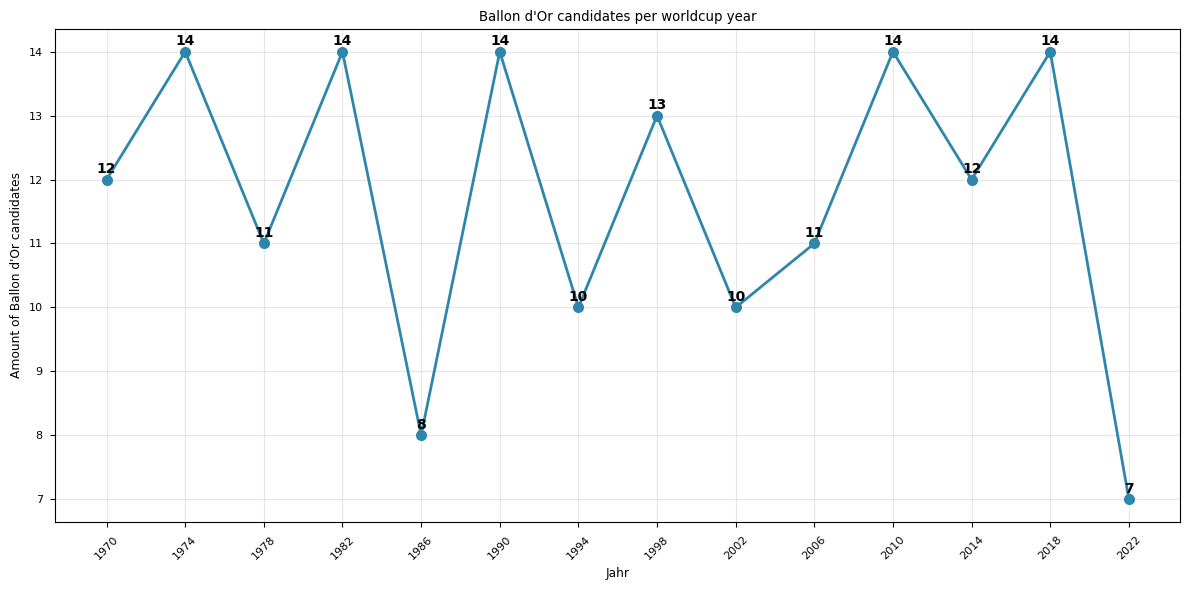

In [260]:
candidate_counts = players_bd_same.groupby("year")["is_bd_candidate_same_year"].sum()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(candidate_counts.index, candidate_counts.values, marker='o', 
        linewidth=2, markersize=8, color='#2E86AB')
ax.set_xlabel('Jahr')
ax.set_ylabel('Amount of Ballon d\'Or candidates')
ax.set_title('Ballon d\'Or candidates per worldcup year')
ax.grid(True, alpha=0.3)
ax.set_xticks(candidate_counts.index)
ax.set_xticklabels(candidate_counts.index, rotation=45)

for year, count in candidate_counts.items():
    ax.text(year, count + 0.1, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [261]:
players_bd_before.groupby("year")["is_bd_candidate_before"].sum()


year
1970     0
1974    12
1978     8
1982    10
1986    10
1990    10
1994     8
1998    10
2002    11
2006     9
2010    10
2014     8
2018    12
2022     7
Name: is_bd_candidate_before, dtype: int64

-----------------------------------------------------------------------------------------------------------------------


This block aggregates player-level information into team-level statistics
for each World Cup year. After merging player data with team placements,
we compute: <br>

<ul>
    <li>number of players per team ("num_players")</li>
    <li>number and presence of Ballon d'Or candidates from the previous year</li>
    <li>number and presence of Ballon d'Or winners from the previous year</li>
    <li>final World Cup placement ("position")</li>
    <li>whether the team became World Cup champion ("is_worldcup_winner")</li>
</ul>



In [262]:
team_summary_before = (
    players_bd_before
    .merge(team_info, on=["year", "team_id", "team_name"], how="left")
    .groupby(["year", "team_id", "team_name", "team_code"], as_index=False)
    .agg(
        num_players                  = ("player_id", "nunique"),
        num_bd_candidates_before     = ("is_bd_candidate_before", "sum"),
        has_bd_candidate_before      = ("is_bd_candidate_before", lambda x: x.any()),
        num_bd_winners_before        = ("is_bd_winner_before", "sum"),
        has_bd_winner_before         = ("is_bd_winner_before", lambda x: x.any()),
        position                     = ("position", "first")  
    )
)

team_summary_before["is_worldcup_winner"] = (team_summary_before["position"] == 1).astype(int)

team_summary_before.tail()
#print(team_summary_before)

,year,team_id,team_name,team_code,num_players,num_bd_candidates_before,has_bd_candidate_before,num_bd_winners_before,has_bd_winner_before,position,is_worldcup_winner
51,2018,T-30,France,FRA,21,2,True,0,False,1.0,1
52,2022,T-03,Argentina,ARG,24,1,True,1,True,1.0,1
53,2022,T-18,Croatia,HRV,21,0,False,0,False,3.0,0
54,2022,T-30,France,FRA,24,1,True,0,False,2.0,0
55,2022,T-47,Morocco,MAR,25,0,False,0,False,4.0,0


Same as done above just for Hypotheses 2:

In [263]:

team_summary_same = (
    players_bd_same
    .groupby(["year", "team_id", "team_name"], as_index=False)
    .agg(
        num_players            = ("player_id", "nunique"),
        num_bd_candidates_same = ("is_bd_candidate_same_year", "sum"),
        has_bd_candidate_same  = ("is_bd_candidate_same_year", lambda x: x.any()),
        num_bd_winners_same    = ("is_bd_winner_same_year", "sum"),
        has_bd_winner_same     = ("is_bd_winner_same_year", lambda x: x.any())
    )
)


team_summary_same = team_summary_same.merge(
    team_info[["year", "team_id", "position"]],
    on=["year", "team_id"],
    how="left"
)

team_summary_same["is_worldcup_winner"] = (team_summary_same["position"] == 1).astype(int)

team_summary_same.tail(10)

,year,team_id,team_name,num_players,num_bd_candidates_same,has_bd_candidate_same,num_bd_winners_same,has_bd_winner_same,position,is_worldcup_winner
358,2022,T-63,Saudi Arabia,23,0,False,0,False,NaN,0
359,2022,T-65,Senegal,20,0,False,0,False,NaN,0
360,2022,T-66,Serbia,22,0,False,0,False,NaN,0
361,2022,T-71,South Korea,21,0,False,0,False,NaN,0
362,2022,T-73,Spain,21,0,False,0,False,NaN,0
363,2022,T-75,Switzerland,24,0,False,0,False,NaN,0
364,2022,T-79,Tunisia,21,0,False,0,False,NaN,0
365,2022,T-83,United States,20,0,False,0,False,NaN,0
366,2022,T-84,Uruguay,19,0,False,0,False,NaN,0
367,2022,T-85,Wales,18,0,False,0,False,NaN,0


<li>Groupby years to see for the years befor wc how many ballondor candidates there have been and how many winners</li>

In [264]:
team_summary_before.groupby("year")[["num_bd_candidates_before", "num_bd_winners_before"]].sum()

,num_bd_candidates_before,num_bd_winners_before
year,,
1970,0,0
1974,5,1
1978,2,0
1982,6,1
1986,5,1
1990,5,0
1994,5,1
1998,4,0
2002,1,0


<li>Groupby years to see how many ballondor candidates and winners in the same year as wc there are</li>

In [265]:
team_summary_same.groupby("year")[["num_bd_candidates_same", "num_bd_winners_same"]].sum()


,num_bd_candidates_same,num_bd_winners_same
year,,
1970,12,1
1974,14,1
1978,11,0
1982,14,1
1986,8,0
1990,14,1
1994,10,1
1998,13,1
2002,10,0


-----------------------------------------------------------------------------------------------------------------------

<h2><center>Descriptive  Statistics</center></h2>

In [266]:
n_world_cups = team_summary_before[team_summary_before["is_worldcup_winner"] == 1].shape[0]

#time range
min_year = team_summary_before["year"].min()
max_year = team_summary_before["year"].max()

print("Dataset Overview")
print("----------------")
print(f"World Cups analyzed: {n_world_cups}")
print(f"Year range: {min_year}–{max_year}")

Dataset Overview
----------------
World Cups analyzed: 14
Year range: 1970–2022


<center>Kontingenztafel</center>

In [267]:
contingency_table = pd.crosstab(
    team_summary_before["is_worldcup_winner"],
    team_summary_before["has_bd_winner_before"],
    rownames=["World Cup Winner"],
    colnames=["Has Ballon d'Or Winner Before"]
)

print("\nContingency Table")
print("-----------------")
print(contingency_table)


Contingency Table
-----------------
Has Ballon d'Or Winner Before  False  True 
World Cup Winner                           
0                                 38      4
1                                 13      1


-----------------------------------------------------------------------------------------------------------------------

<center>Ballondor Statistics</center>

-----------------------------------------------------------------------------------------------------------------------

<h4><center>Test's</center></h4>

Hypothesis 1: <br>
BD candidates in the previous year → influence on WM win?<br>

Construct a 2x2 matrix tabel to compare possibilitys:

<ul> 
    <li>is_woldcup_winner = 1 → has won wc</li>
    <li>has_bd_winner_before = 1 → has won bd year before wc</li>
</ul>
<br>
This shows how often the winning team has a ballondor winner in their team and how often not and of there is even a correlation.<br>
Apply Fishers Exact Test to determin the statistical significance assosiated between the 2 variables.



In [268]:
cont_before = pd.crosstab(
    team_summary_before["is_worldcup_winner"],
    team_summary_before["has_bd_winner_before"]
)

print("Contingency table: previous year's Ballon d'Or winner vs. World Cup victory:")
print(cont_before)

oddsratio_before, p_before = fisher_exact(cont_before)
print("Fisher's exact test (previous year):")
print("Odds ratio:", oddsratio_before)
print("p-value:", p_before)


Contingency table: previous year's Ballon d'Or winner vs. World Cup victory:
has_bd_winner_before  False  True 
is_worldcup_winner                
0                        38      4
1                        13      1
Fisher's exact test (previous year):
Odds ratio: 0.7307692307692307
p-value: 1.0


c:\Users\PC\anaconda3\Lib\site-packages\statsmodels\graphics\mosaicplot.py:651: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)


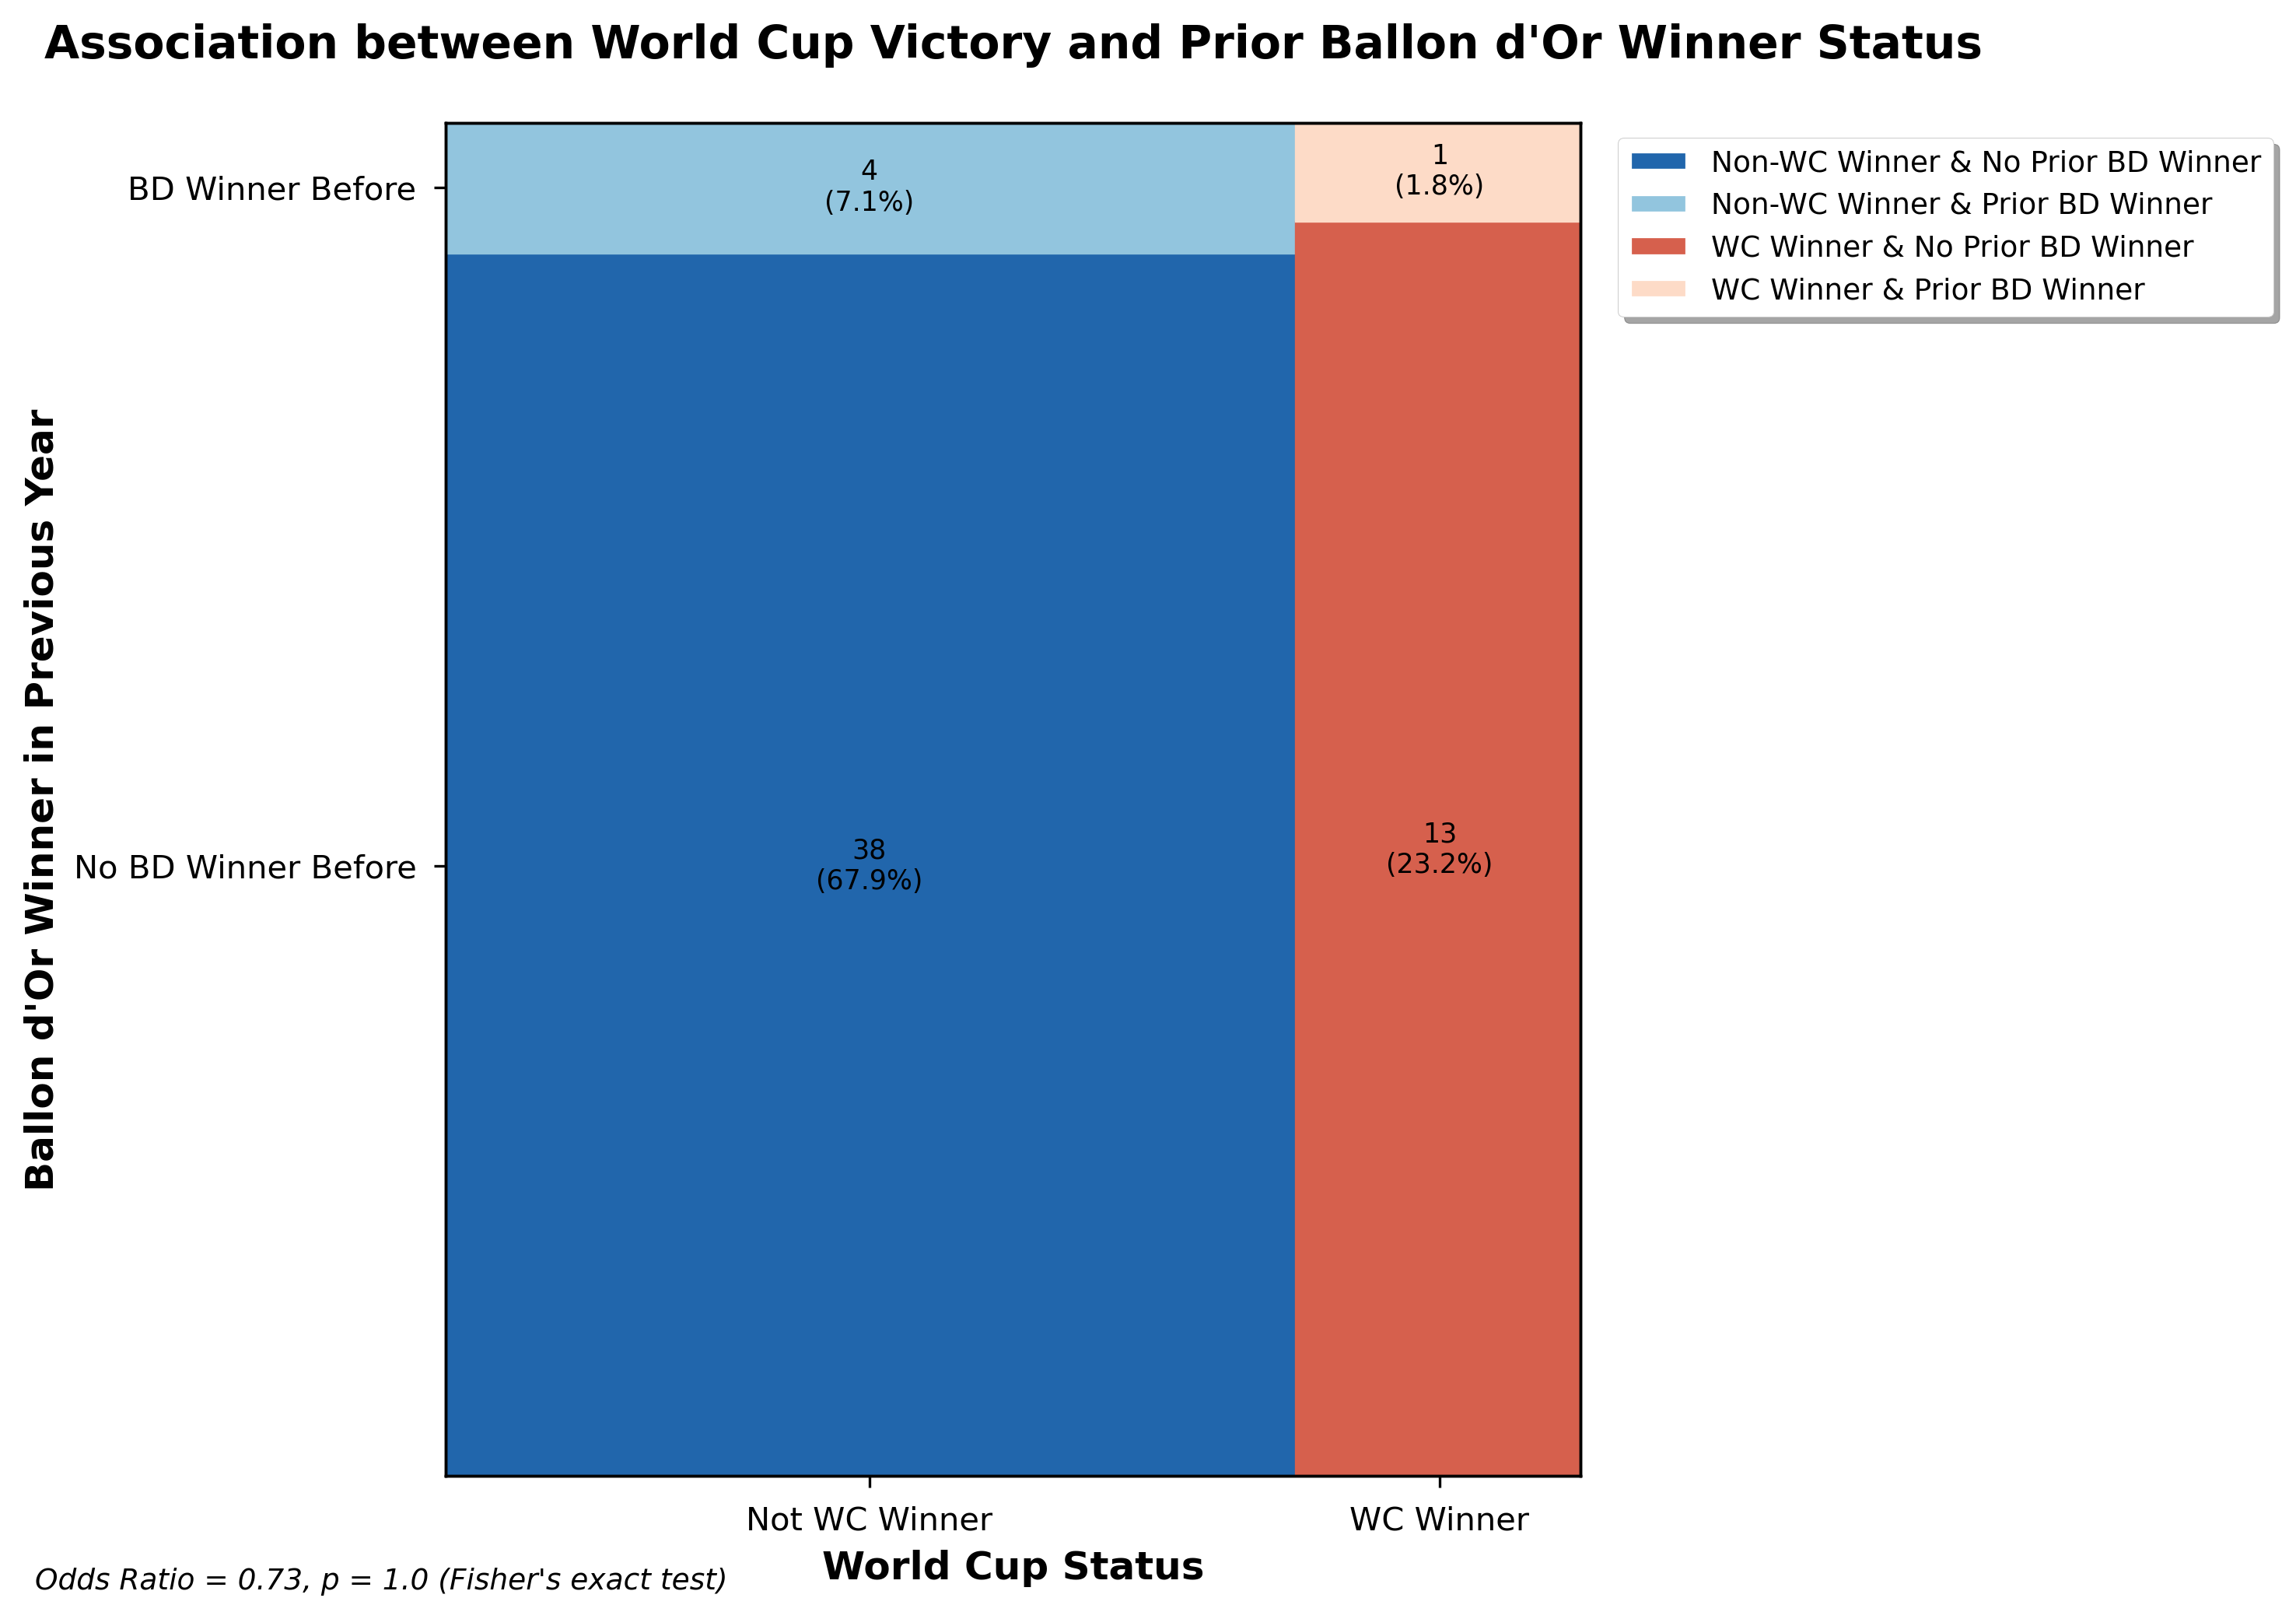

In [269]:
contingency_table = pd.DataFrame({
    False: [38, 13],
    True: [4, 1]
}, index=[0, 1])

colors = {
    (0, False): '#2166ac',
    (0, True): '#92c5de',
    (1, False): '#d6604d',
    (1, True): '#fddbc7'
}

mosaic_data = {
    ("Not WC Winner", "No BD Winner Before"): 38,
    ("Not WC Winner", "BD Winner Before"): 4,
    ("WC Winner", "No BD Winner Before"): 13,
    ("WC Winner", "BD Winner Before"): 1,
}

colors_mosaic = {
    ("Not WC Winner", "No BD Winner Before"): '#2166ac',
    ("Not WC Winner", "BD Winner Before"): '#92c5de',
    ("WC Winner", "No BD Winner Before"): '#d6604d',
    ("WC Winner", "BD Winner Before"): '#fddbc7'
}

fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

mosaic(mosaic_data, 
       ax=ax,
       properties=lambda key: {'color': colors_mosaic[key], 
                               'edgecolor': 'white',
                               'linewidth': 2},
       labelizer=lambda k: f'{mosaic_data[k]}\n({100*mosaic_data[k]/sum(mosaic_data.values()):.1f}%)',
       label_rotation=[0, 0])

ax.set_title('Association between World Cup Victory and Prior Ballon d\'Or Winner Status',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('World Cup Status', fontsize=12, fontweight='bold')
ax.set_ylabel('Ballon d\'Or Winner in Previous Year', fontsize=12, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2166ac', label='Non-WC Winner & No Prior BD Winner', edgecolor='white', linewidth=1.5),
    Patch(facecolor='#92c5de', label='Non-WC Winner & Prior BD Winner', edgecolor='white', linewidth=1.5),
    Patch(facecolor='#d6604d', label='WC Winner & No Prior BD Winner', edgecolor='white', linewidth=1.5),
    Patch(facecolor='#fddbc7', label='WC Winner & Prior BD Winner', edgecolor='white', linewidth=1.5)
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), 
          fontsize=9, frameon=True, shadow=True)

fig.text(0.02, 0.02, f'Odds Ratio = 0.73, p = 1.0 (Fisher\'s exact test)', 
         fontsize=9, style='italic', color='black')

plt.tight_layout()
plt.show()

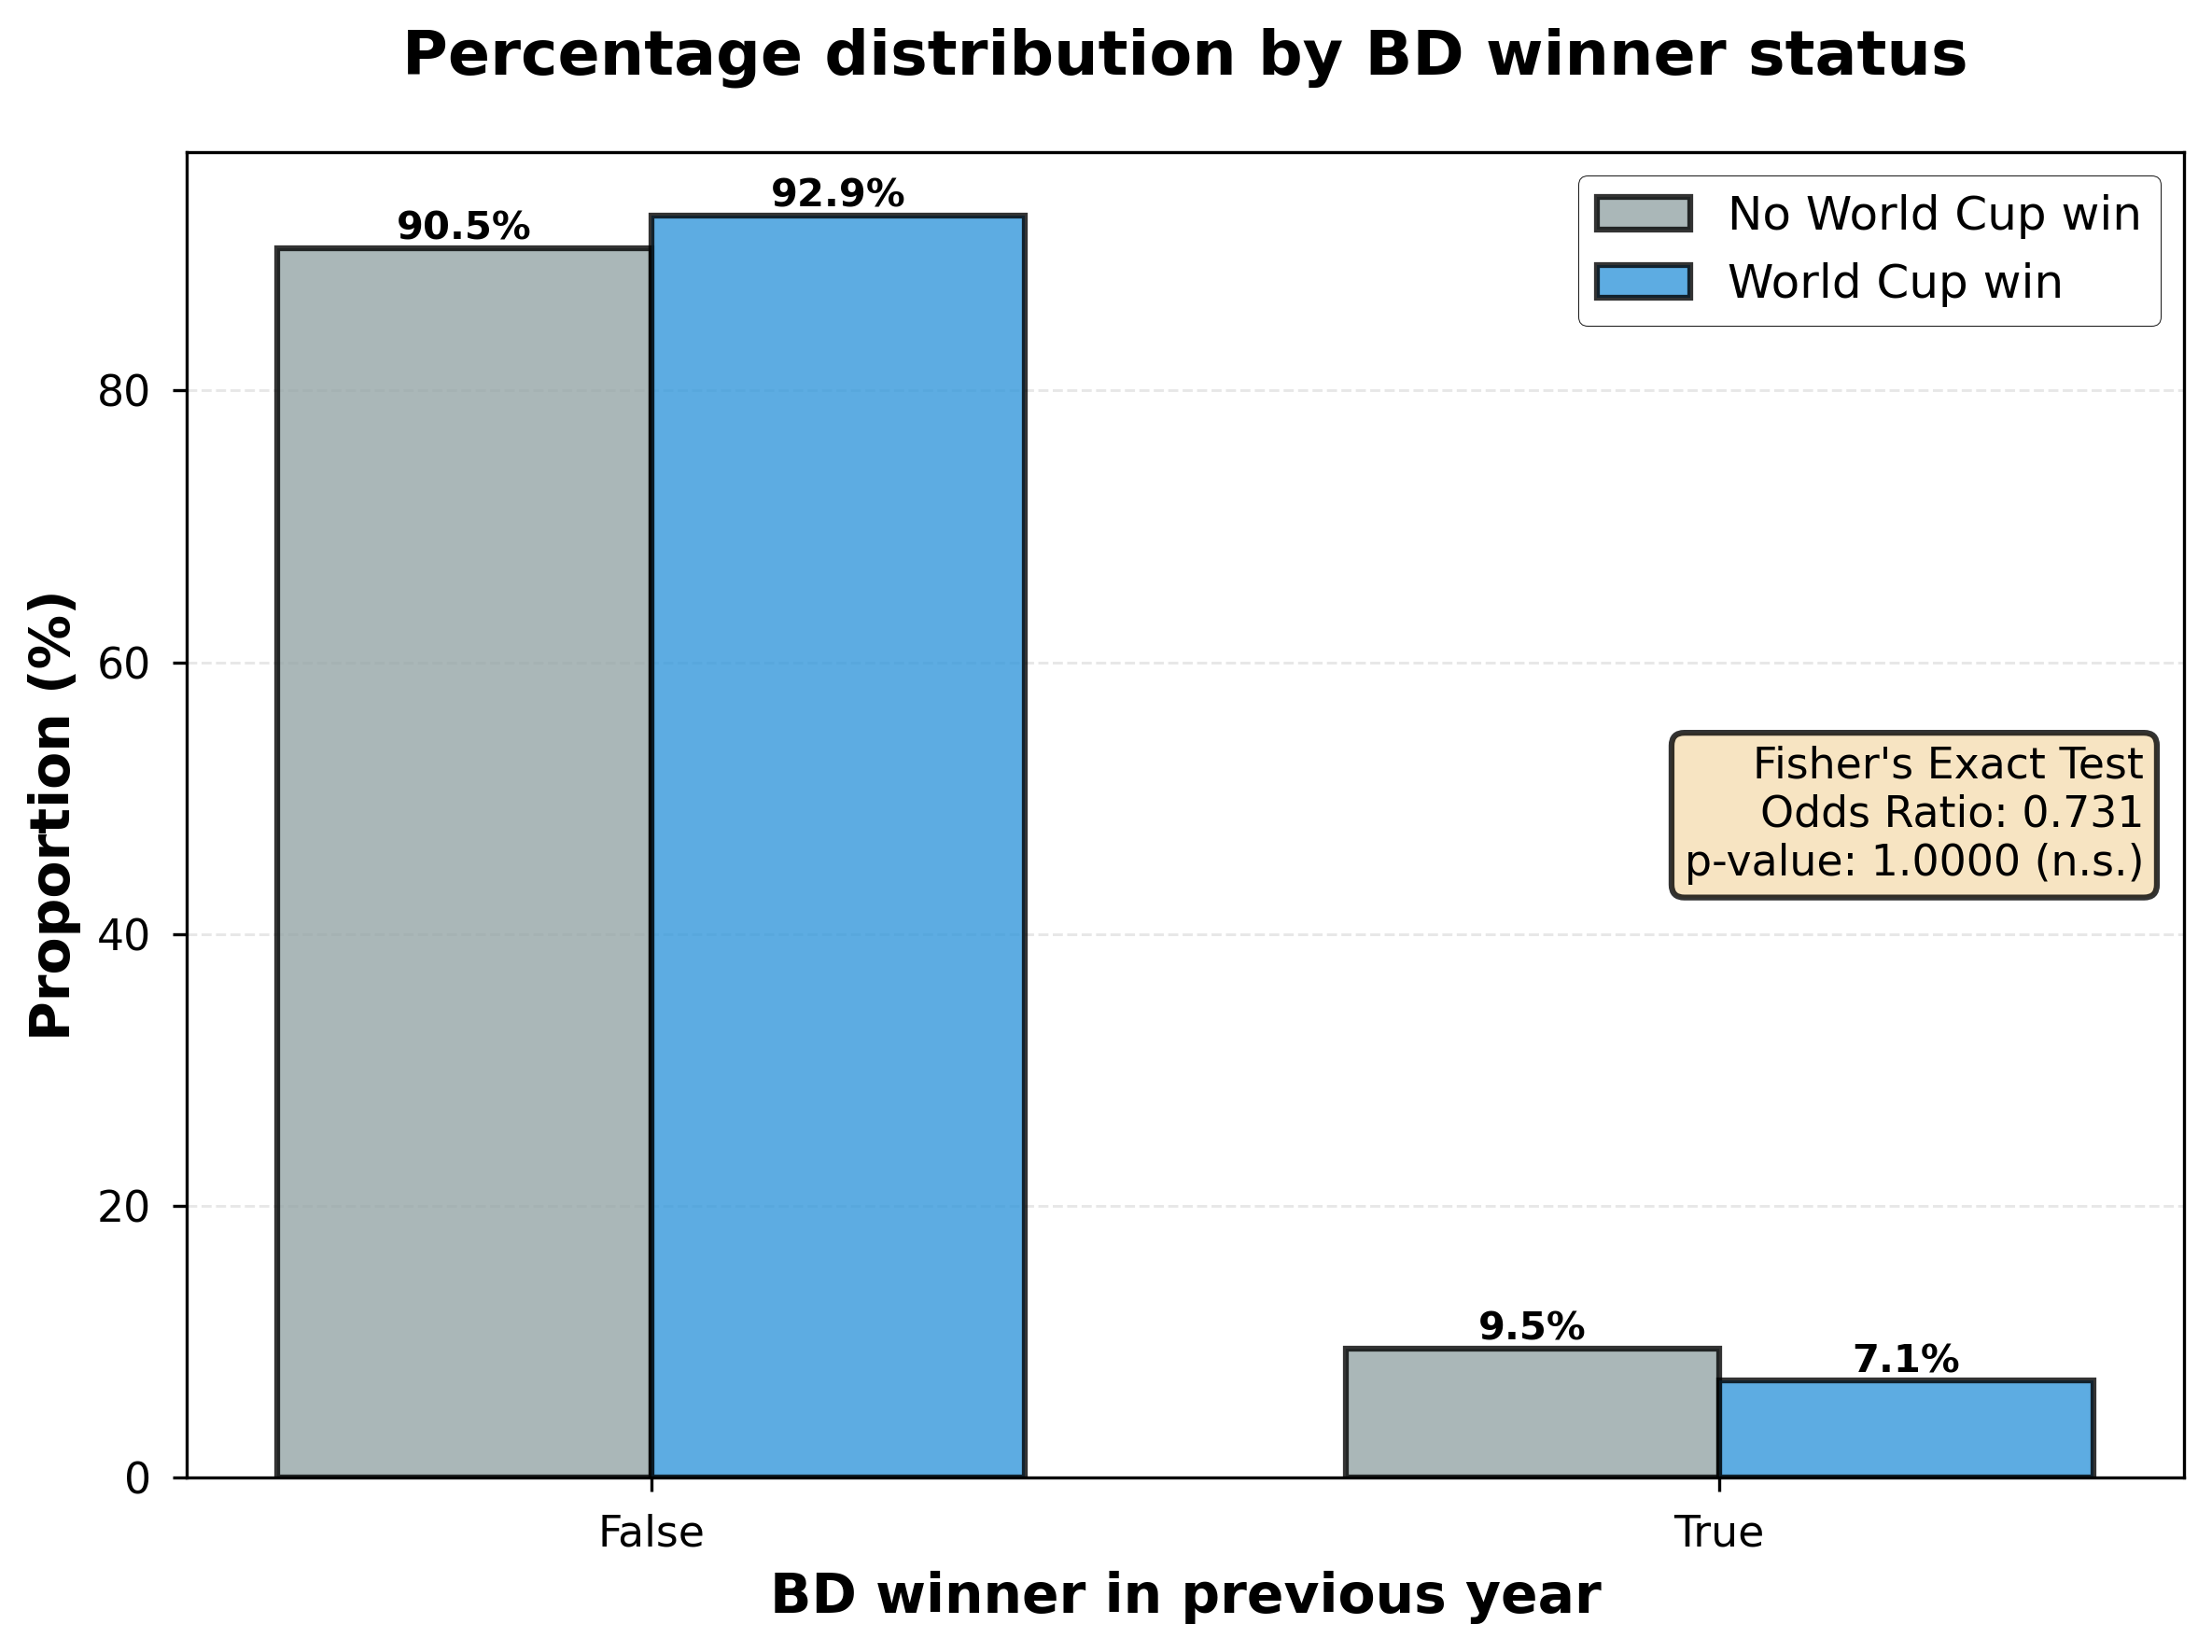

In [270]:
#Claud AI was used to improve the plots quality

cont_before = pd.crosstab(
    team_summary_before["is_worldcup_winner"],
    team_summary_before["has_bd_winner_before"],
    rownames=['World Cup winner'],
    colnames=['BD winner (previous year)']
)

oddsratio_before, p_before = fisher_exact(cont_before)

plt.style.use('seaborn-v0_8-paper')

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
cont_pct = cont_before.div(cont_before.sum(axis=1), axis=0) * 100
x = range(len(cont_pct.columns))
width = 0.35

bars1 = ax.bar(
    [i - width/2 for i in x],
    cont_pct.iloc[0],
    width,
    label='No World Cup win',
    color='#95a5a6',
    edgecolor='black',
    linewidth=1.5,
    alpha=0.8
)
bars2 = ax.bar(
    [i + width/2 for i in x],
    cont_pct.iloc[1],
    width,
    label='World Cup win',
    color='#3498db',
    edgecolor='black',
    linewidth=1.5,
    alpha=0.8
)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f'{height:.1f}%',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

ax.set_xlabel('BD winner in previous year', fontsize=14, fontweight='bold')
ax.set_ylabel('Proportion (%)', fontsize=14, fontweight='bold')
ax.set_title(
    'Percentage distribution by BD winner status',
    fontsize=16,
    fontweight='bold',
    pad=20
)
ax.set_xticks(x)
ax.set_xticklabels(cont_before.columns, fontsize=12)
ax.legend(fontsize=12, framealpha=0.9, edgecolor='black', loc='upper right')

ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)
ax.tick_params(axis='both', labelsize=11)

sig_text = (
    "***" if p_before < 0.001
    else "**" if p_before < 0.01
    else "*" if p_before < 0.05
    else "n.s."
)
stats_text = (
    "Fisher's Exact Test\n"
    f"Odds Ratio: {oddsratio_before:.3f}\n"
    f"p-value: {p_before:.4f} ({sig_text})"
)

ax.text(
    0.98,
    0.5,
    stats_text,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment='center',
    horizontalalignment='right',
    bbox=dict(
        boxstyle='round',
        facecolor='wheat',
        alpha=0.8,
        edgecolor='black',
        linewidth=1.5
    )
)

plt.tight_layout()
plt.show()


-----------------------------------------------------------------------------------------------------------------------

Hypothesis 2:<br>
WC win → Better Ballon d’Or ranking in the same year?<br>
Prep ballndor data set<br>

First create a colum to have a binary value to check if the player is wc winner.<br>
Then extract players how have a ranking in ballondor of the year of wc.<br>
Therefor we only use two Variables "Rank" and "is_worldcup_winner"<br>



In [271]:
players_bd_same["is_worldcup_winner_team"] = (players_bd_same["position"] == 1).astype(int)

bd_ranks = players_bd_same.loc[
    players_bd_same["Rank"].notna(),
    ["Rank","player_fullname","is_worldcup_winner_team"]
].copy()

bd_ranks["Rank"] = bd_ranks["Rank"].astype(int)
bd_ranks["player_fullname"] = bd_ranks["player_fullname"].astype(str)
bd_ranks["is_worldcup_winner_team"] = bd_ranks["is_worldcup_winner_team"].astype(int)

bd_ranks.tail(10)
#players_bd_same.head()


,Rank,player_fullname,is_worldcup_winner_team
5893,6,mohamed salah,0
5982,3,antoine griezmann,1
6020,11,n'golo kanté,1
6034,4,robert lewandowski,0
6092,7,thibaut courtois,0
6208,15,rafael leão,0
6229,9,luka modrić,0
6368,3,kevin de bruyne,0
6468,6,kylian mbappé,0
6668,8,vinícius júnior,0


Spliting ballondor ranked players it the two groups where one is the winner of wc and the rest in a dfferent group. <br>
These two distributions are required for the Mann–Whitney U test, which examines
whether players from World Cup winning teams achieve significantly better/lower Ballon d'Or rankings in the same year

In [272]:
winner_ranks = bd_ranks[bd_ranks["is_worldcup_winner_team"] == 1]["Rank"]
other_ranks  = bd_ranks[bd_ranks["is_worldcup_winner_team"] == 0]["Rank"]

winner_ranks.head()



398      4
455     12
462      7
464      2
1002     8
Name: Rank, dtype: int64

Convert to integer

In [273]:
winner_ranks = winner_ranks.astype(int)
other_ranks  = other_ranks.astype(int)

In [274]:

stat, p = mannwhitneyu(winner_ranks, other_ranks, alternative="two-sided")
print("Mann-Whitney U:", stat)
print("p-value:", p)


Mann-Whitney U: 2216.0
p-value: 0.39223829988645753


C:\Users\PC\AppData\Local\Temp\ipykernel_24612\601641511.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([winner_ranks, other_ranks],


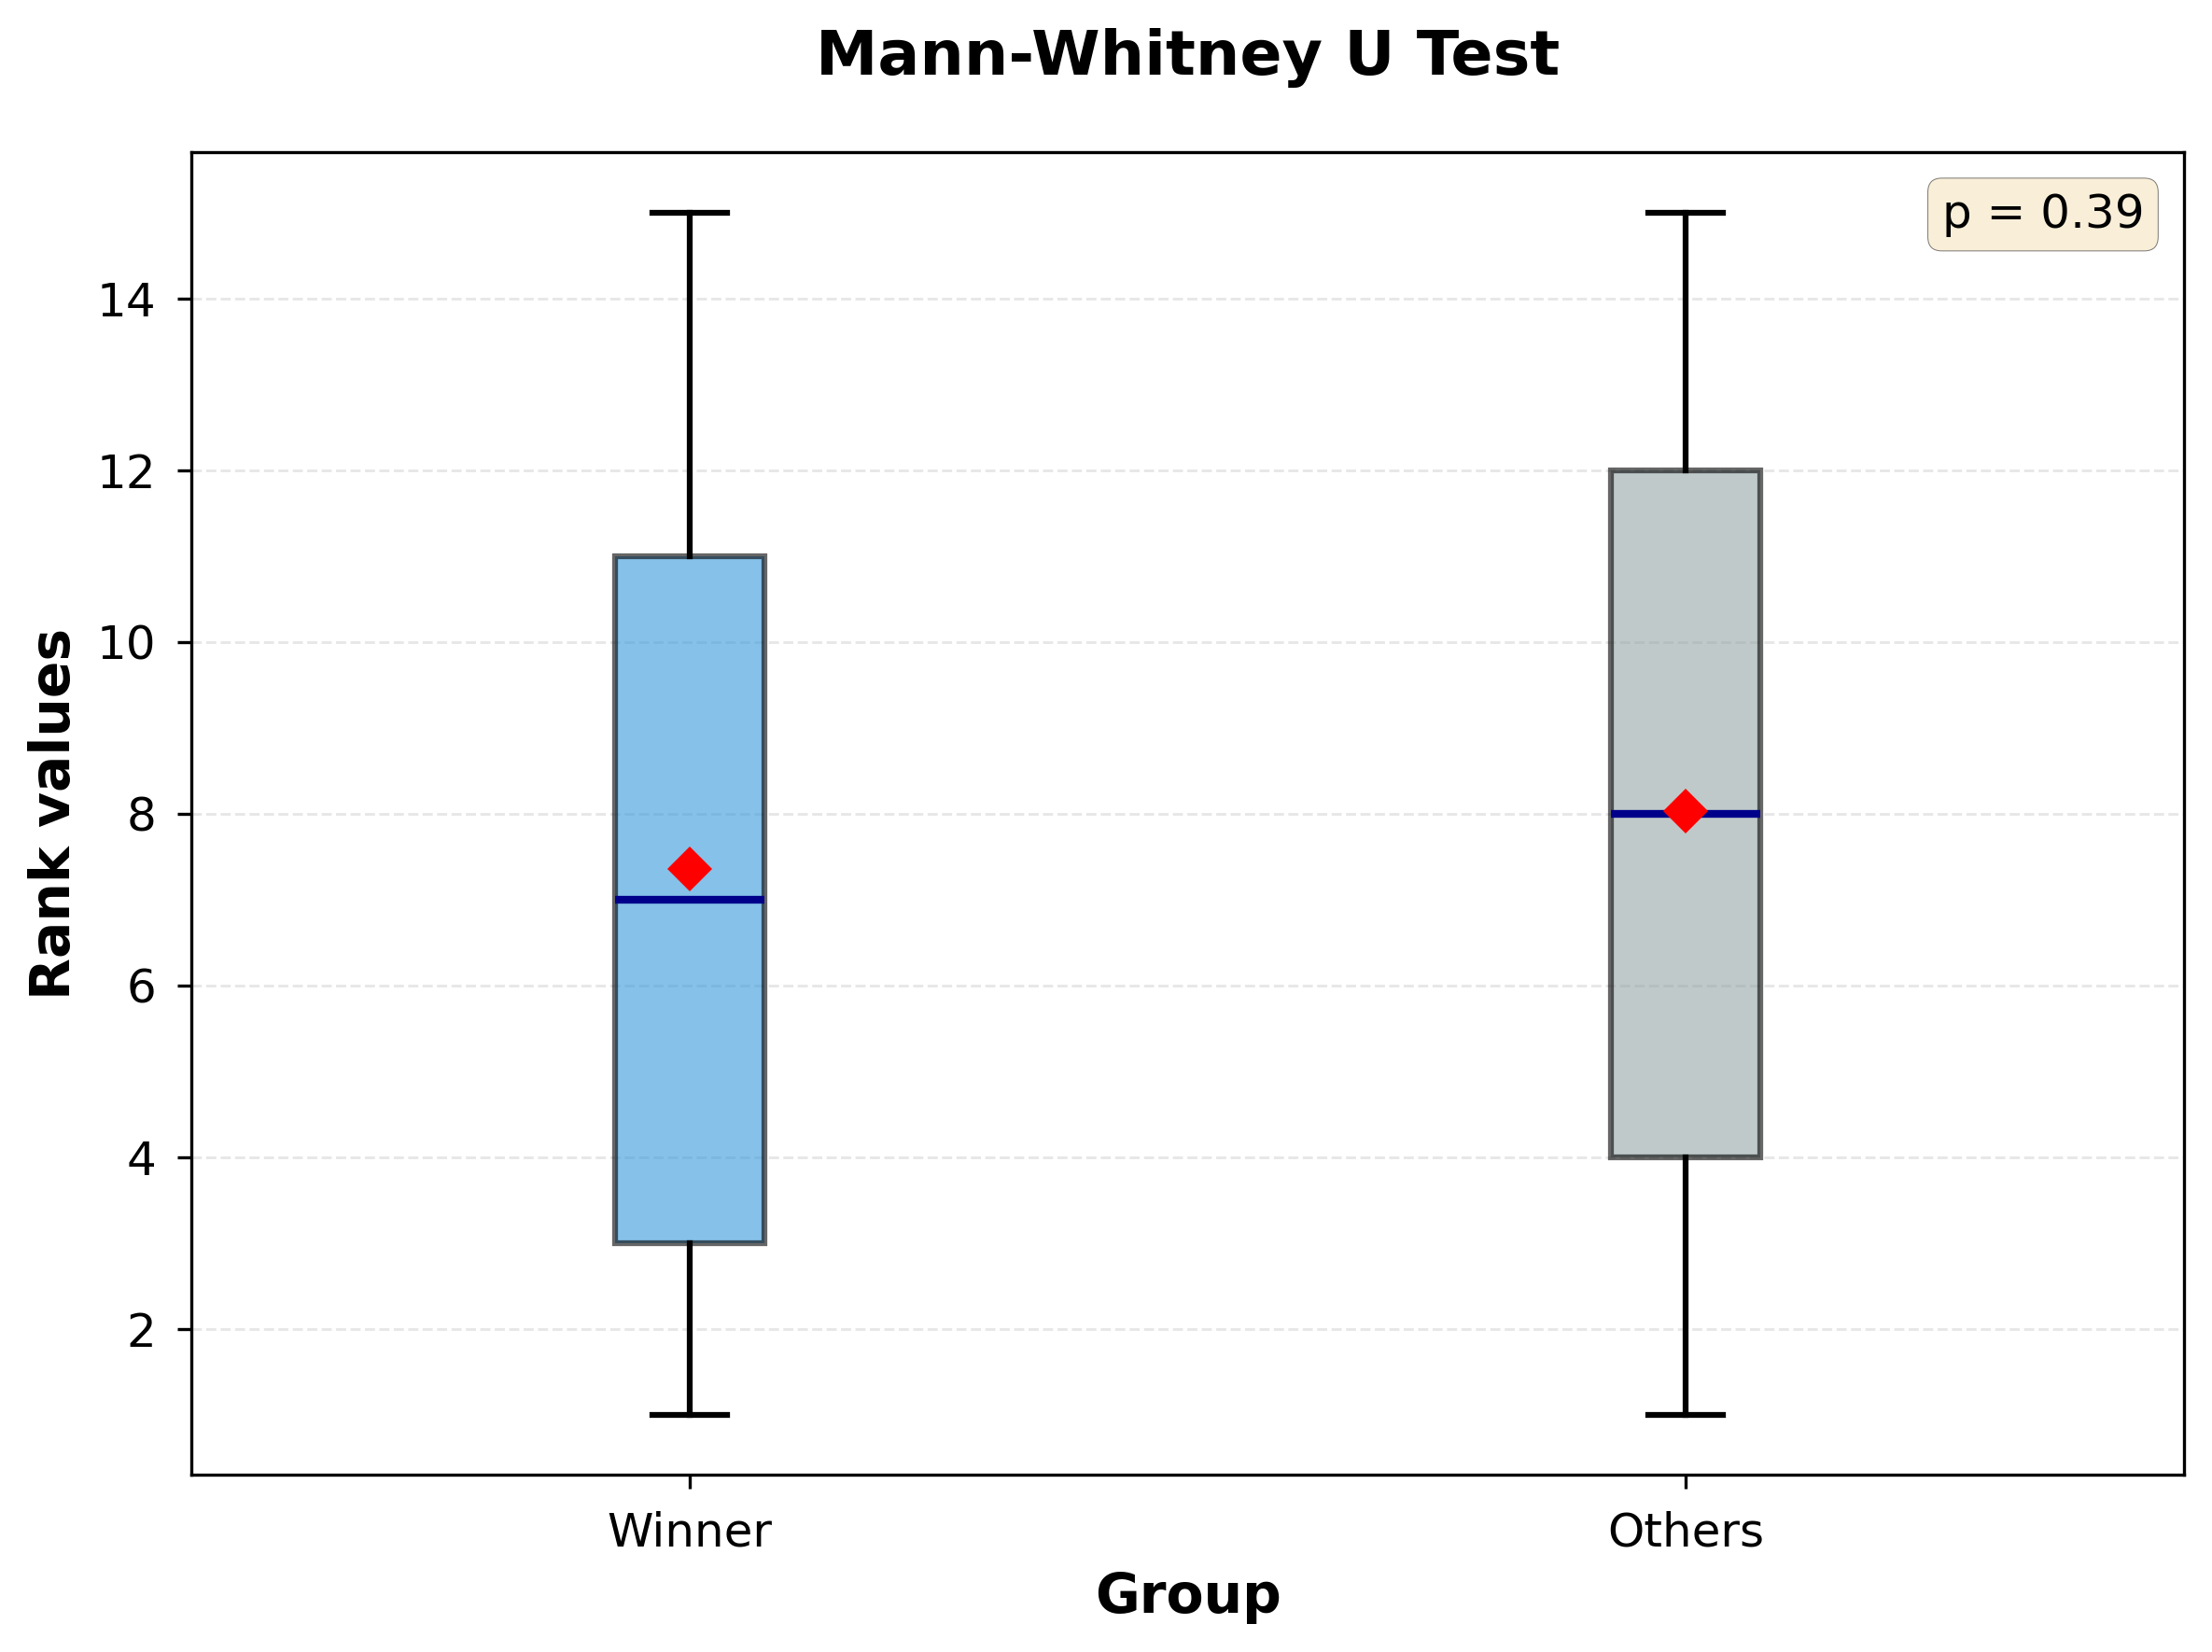

In [275]:
plt.style.use('seaborn-v0_8-paper')
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

bp = ax.boxplot([winner_ranks, other_ranks],
                labels=["Winner", "Others"],
                showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='red',
                               markeredgecolor='darkred', markersize=8),
                medianprops=dict(color='darkblue', linewidth=2),
                boxprops=dict(linewidth=1.5, color='black'),
                whiskerprops=dict(linewidth=1.5, color='black'),
                capprops=dict(linewidth=1.5, color='black'),
                flierprops=dict(marker='o', markerfacecolor='gray',
                                markersize=6, alpha=0.5),
                patch_artist=True)

colors = ['#3498db', '#95a5a6']  #blue for winner, gray for others
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_title("Mann-Whitney U Test", fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel("Rank values", fontsize=14, fontweight='bold')
ax.set_xlabel("Group", fontsize=14, fontweight='bold')

#textbox for the  p-value
ax.text(0.98, 0.97, 'p = 0.39',
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.grid(axis="y", alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)
ax.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
#safe as picture and pdf for paper
plt.savefig('mann_whitney_test.png', dpi=300, bbox_inches='tight')
plt.savefig('mann_whitney_test.pdf', bbox_inches='tight') 
plt.show()


C:\Users\PC\AppData\Local\Temp\ipykernel_24612\2370735703.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([winner_ranks, other_ranks],


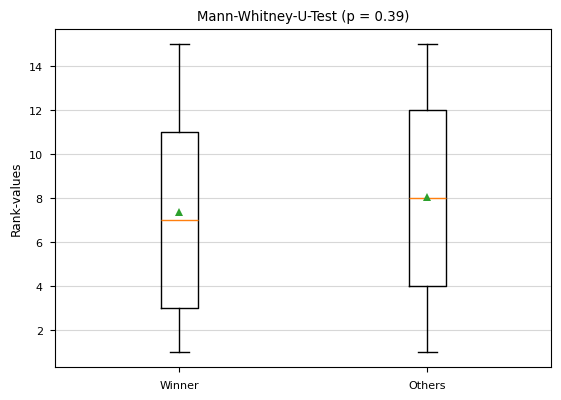

In [276]:
plt.boxplot([winner_ranks, other_ranks],
            labels=["Winner", "Others"],
            showmeans=True)

plt.title("Mann-Whitney-U-Test (p = 0.39)")
plt.ylabel("Rank-values")
plt.grid(axis="y", alpha=0.5)
plt.show()


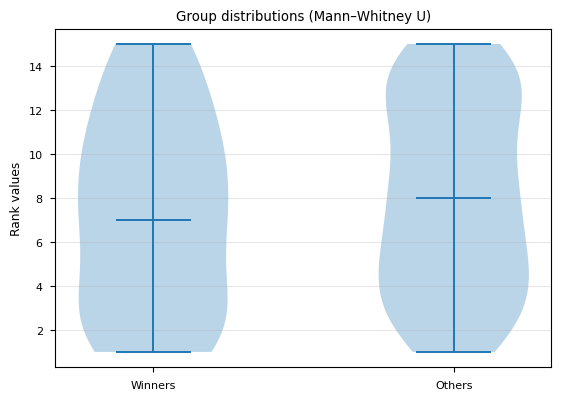

In [277]:
plt.violinplot([winner_ranks, other_ranks], showmedians=True)

plt.xticks([1, 2], ["Winners", "Others"])
plt.title("Group distributions (Mann–Whitney U)")
plt.ylabel("Rank values")
plt.grid(axis="y", alpha=0.3)
plt.show()


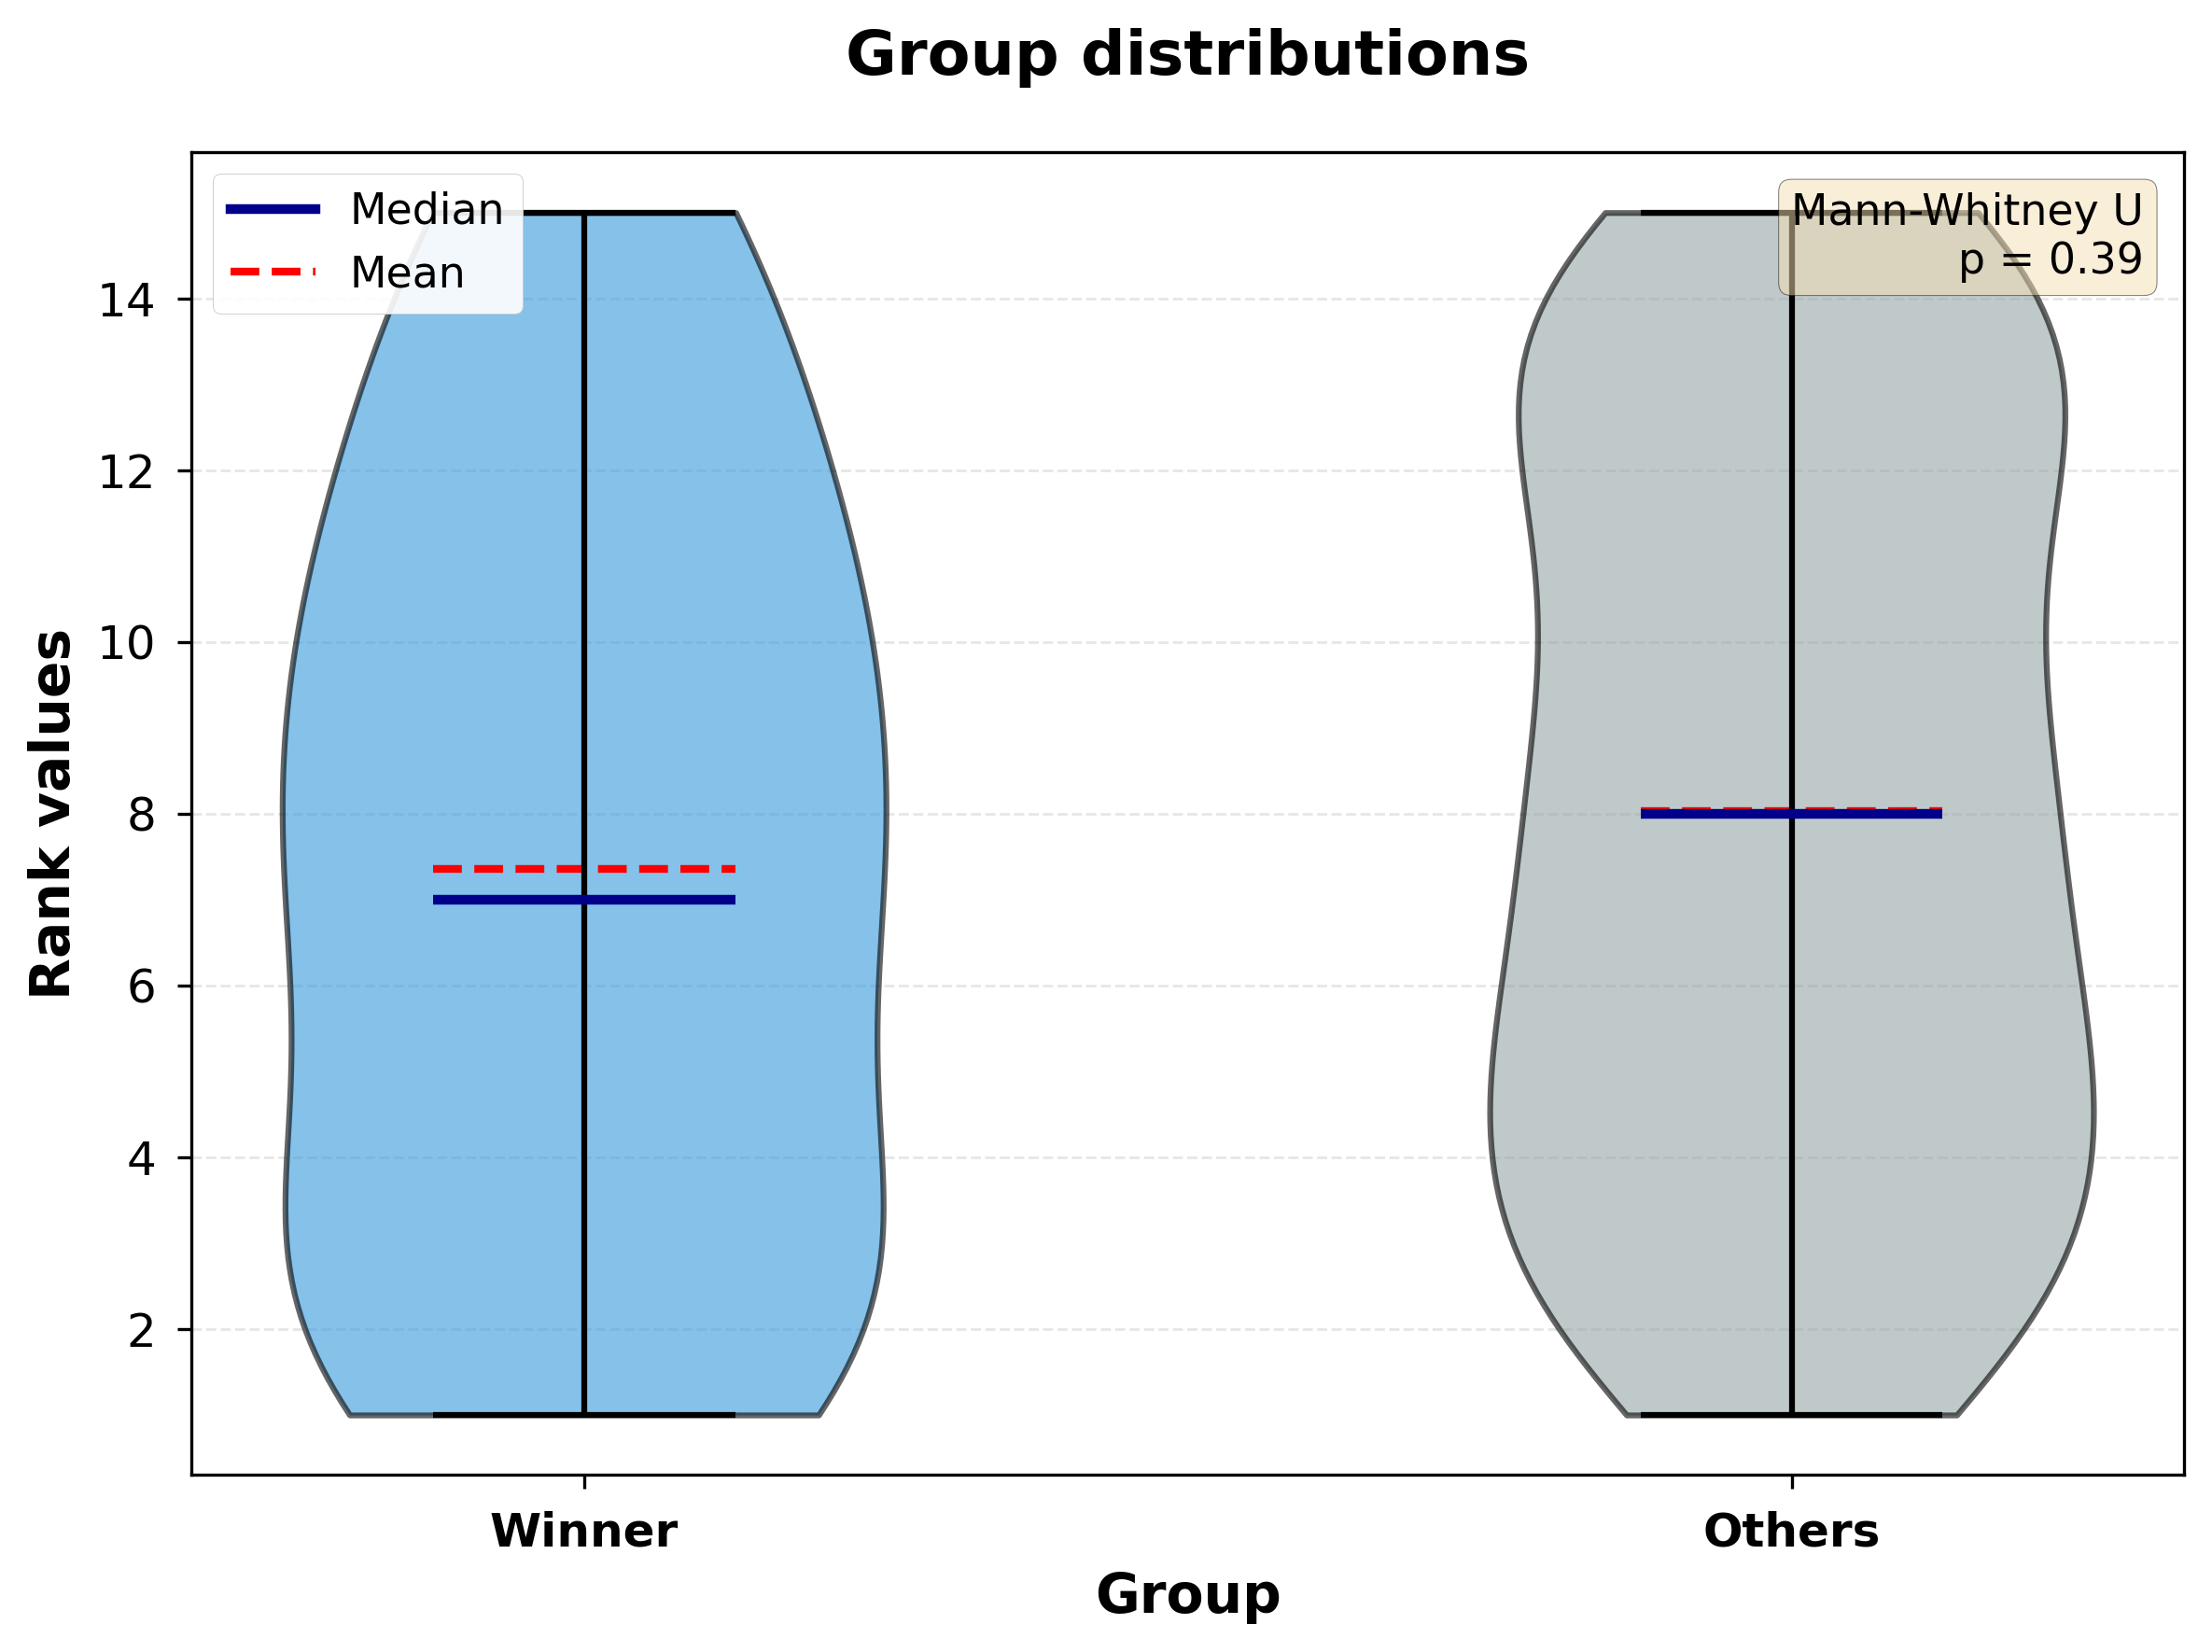

In [278]:
plt.style.use('seaborn-v0_8-paper')  # [web:19]
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)  


parts = ax.violinplot([winner_ranks, other_ranks],
                      showmedians=True,
                      showextrema=True,
                      showmeans=True) 

colors = ['#3498db', '#95a5a6'] 
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.6)
    pc.set_edgecolor('black')
    pc.set_linewidth(1.5)

parts['cmedians'].set_edgecolor('darkblue')
parts['cmedians'].set_linewidth(2.5)

parts['cmaxes'].set_edgecolor('black')
parts['cmaxes'].set_linewidth(1.5)
parts['cmins'].set_edgecolor('black')
parts['cmins'].set_linewidth(1.5)
parts['cbars'].set_edgecolor('black')
parts['cbars'].set_linewidth(1.5)

parts['cmeans'].set_edgecolor('red')
parts['cmeans'].set_linewidth(2)
parts['cmeans'].set_linestyle('--')

ax.set_xticks([1, 2])
ax.set_xticklabels(["Winner", "Others"], fontsize=14, fontweight='bold')
ax.set_ylabel("Rank values", fontsize=14, fontweight='bold')
ax.set_xlabel("Group", fontsize=14, fontweight='bold')

ax.set_title("Group distributions", fontsize=16, fontweight='bold', pad=20)
ax.text(0.98, 0.97, 'Mann-Whitney U\np = 0.39',
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))



legend_elements = [
    Line2D([0], [0], color='darkblue', lw=2.5, label='Median'),
    Line2D([0], [0], color='red', lw=2, linestyle='--', label='Mean')
]  
ax.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.9)

ax.grid(axis="y", alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)
ax.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()

#output png and pdf for paper
plt.savefig('mann_whitney_violin.png', dpi=300, bbox_inches='tight')
plt.savefig('mann_whitney_violin.pdf', bbox_inches='tight')  
plt.show()


-----------------------------------------------------------------------------------------------------------------------

Permutationstest


In [279]:
observed_diff = (
    bd_ranks.loc[bd_ranks["is_worldcup_winner_team"] == 1, "Rank"].median()
    - bd_ranks.loc[bd_ranks["is_worldcup_winner_team"] == 0, "Rank"].median()
)

print(f"Observed difference between both medians is: {observed_diff}")


Observed difference between both medians is: -1.0


In [280]:
import numpy as np

n_perm = 10000
perm_diffs = []

for _ in range(n_perm):
    shuffled = bd_ranks["is_worldcup_winner_team"].sample(frac=1, replace=False).values
    perm_diff = (
        bd_ranks.loc[shuffled == 1, "Rank"].median()
        - bd_ranks.loc[shuffled == 0, "Rank"].median()
    )
    perm_diffs.append(perm_diff)

perm_diffs = np.array(perm_diffs)


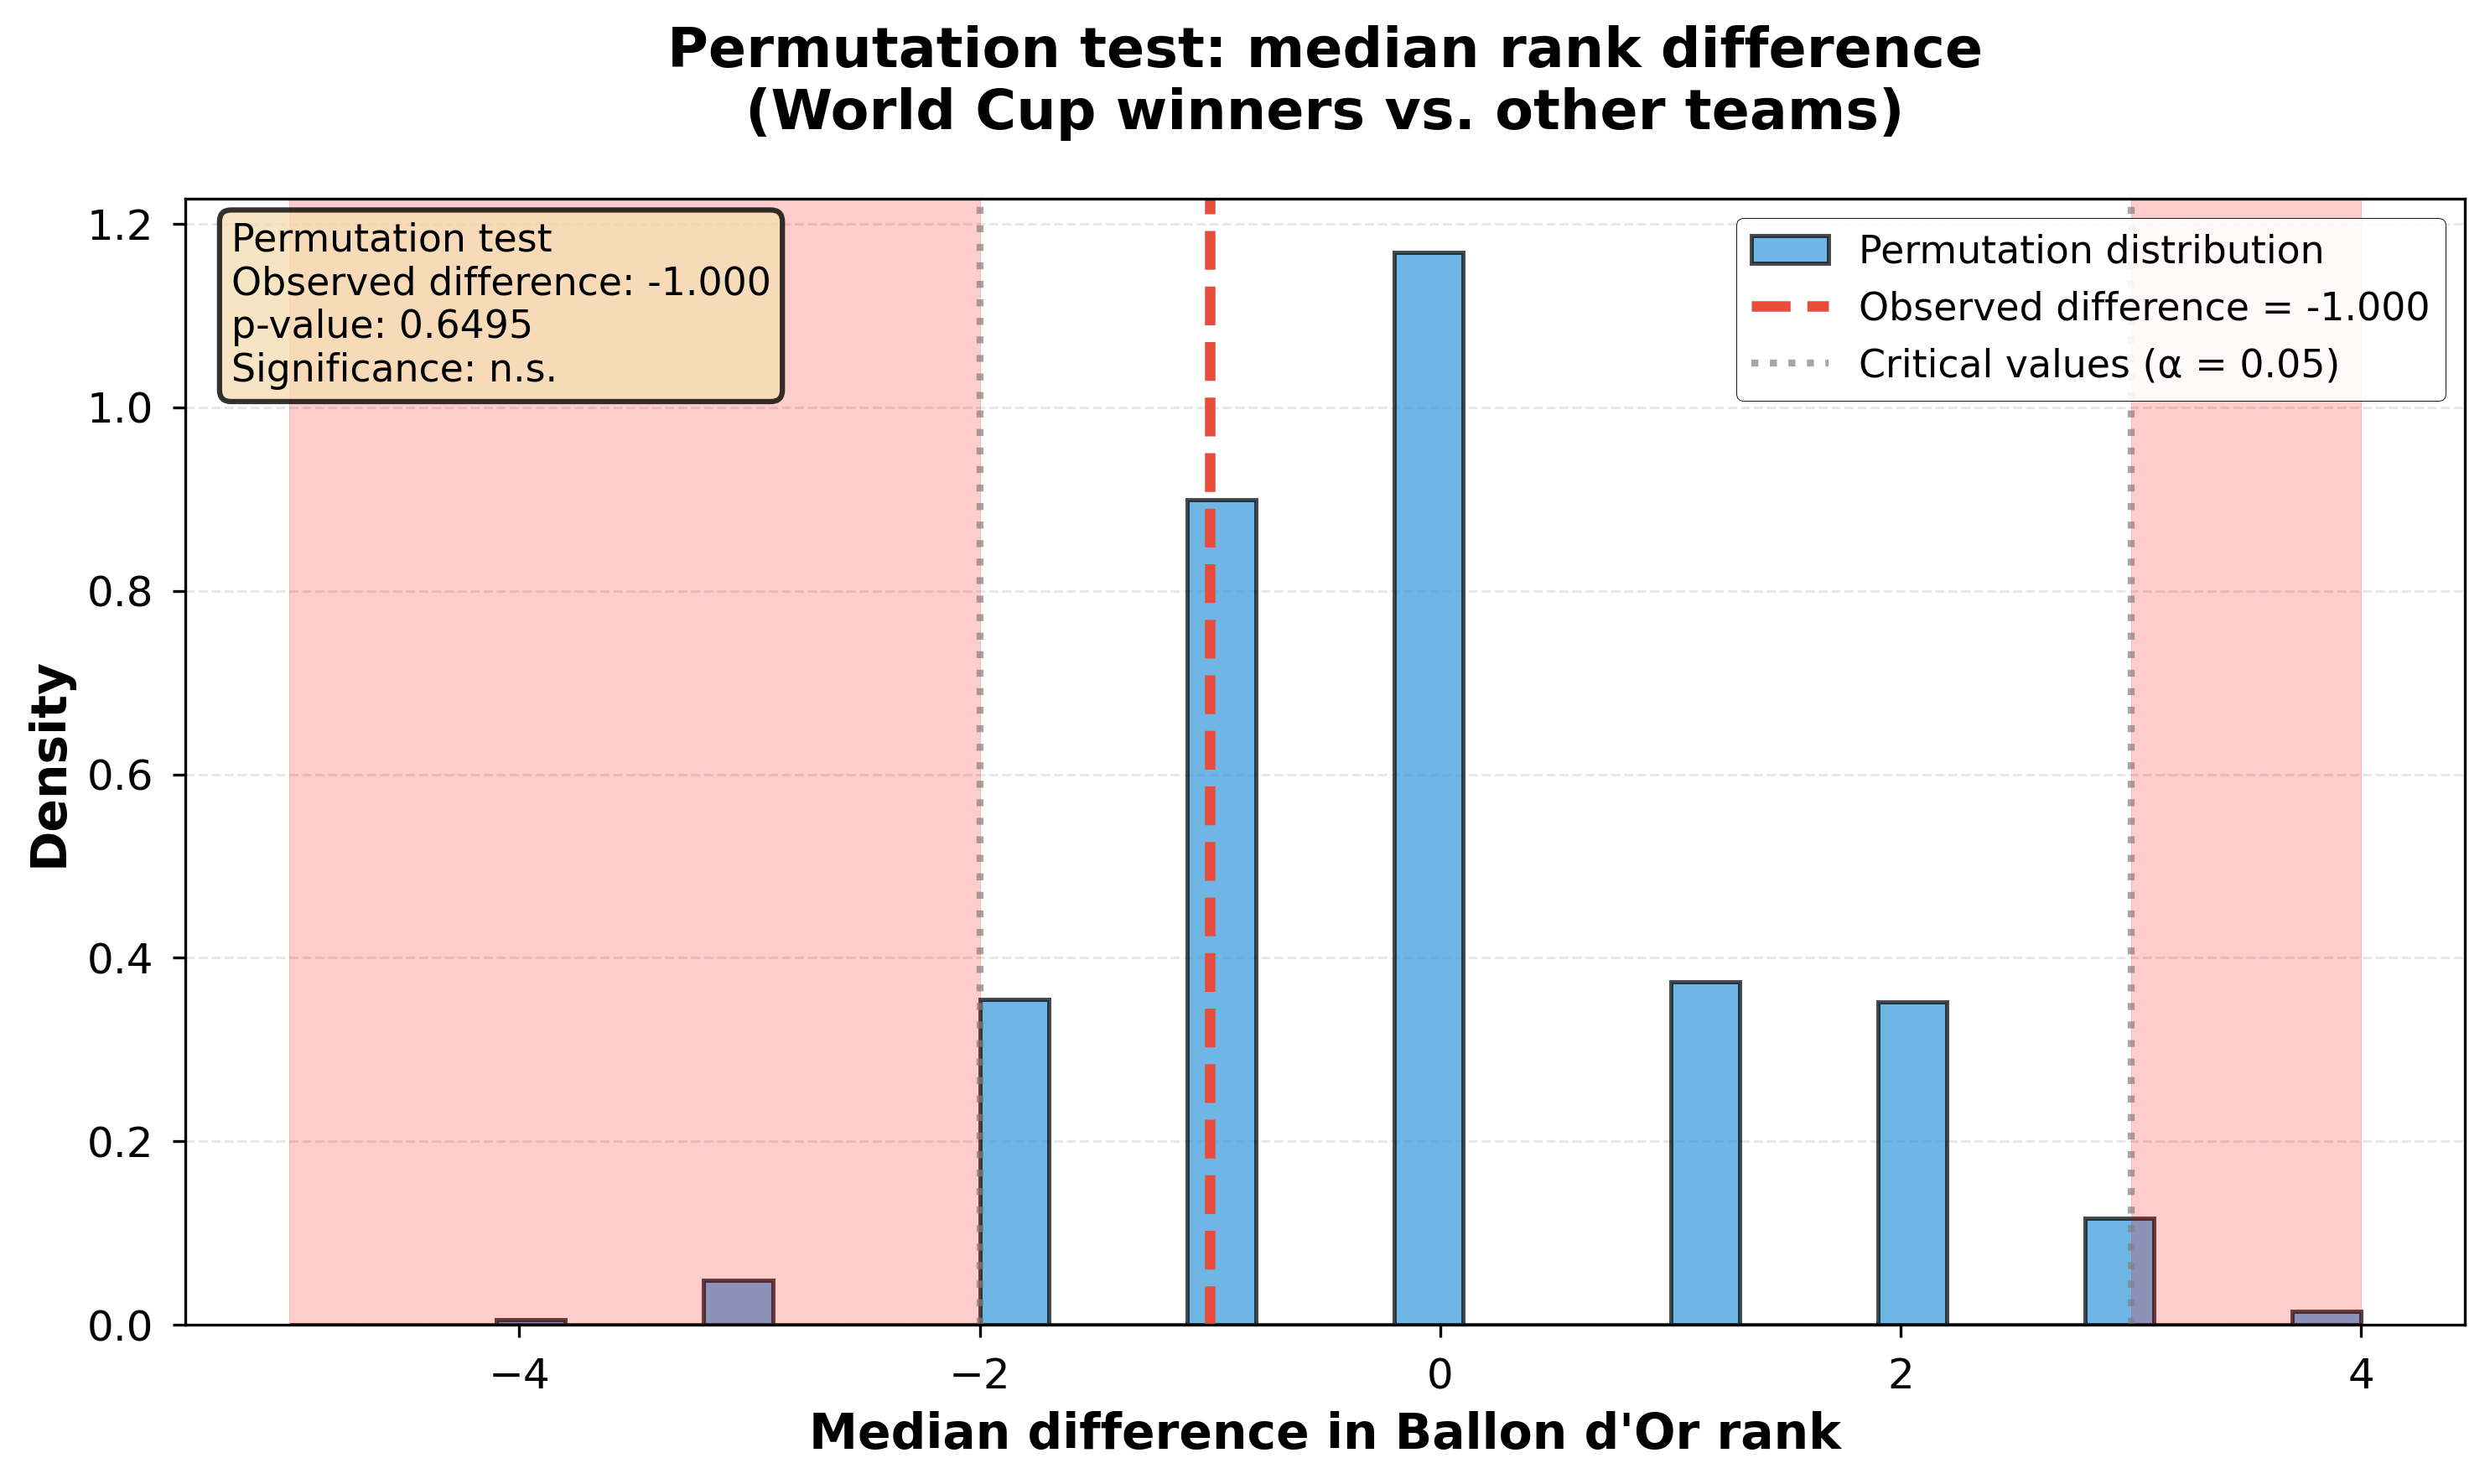

In [281]:
plt.style.use('seaborn-v0_8-paper')  
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)  

n, bins, patches = ax.hist(
    perm_diffs,
    bins=30,
    density=True,
    alpha=0.7,
    color='#3498db',
    edgecolor='black',
    linewidth=1.2,
    label='Permutation distribution'
)  

p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))

ax.axvline(
    observed_diff,
    color='#e74c3c',
    linestyle='--',
    linewidth=3,
    label=f'Observed difference = {observed_diff:.3f}'
) 

alpha_level = 0.05
lower_crit = np.percentile(perm_diffs, alpha_level / 2 * 100)
upper_crit = np.percentile(perm_diffs, (1 - alpha_level / 2) * 100) 


ax.axvline(lower_crit, color='gray', linestyle=':', linewidth=2, alpha=0.7)
ax.axvline(
    upper_crit,
    color='gray',
    linestyle=':',
    linewidth=2,
    alpha=0.7,
    label=f'Critical values (α = {alpha_level})'
)

ax.axvspan(perm_diffs.min(), lower_crit, alpha=0.2, color='red')
ax.axvspan(upper_crit, perm_diffs.max(), alpha=0.2, color='red')  # [web:29]
ax.set_xlabel(
    "Median difference in Ballon d'Or rank",
    fontsize=14,
    fontweight='bold'
)
ax.set_ylabel("Density", fontsize=14, fontweight='bold')
ax.set_title(
    "Permutation test: median rank difference\n(World Cup winners vs. other teams)",
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.legend(fontsize=11, framealpha=0.9, edgecolor='black', loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)
ax.tick_params(axis='both', which='major', labelsize=12)

stats_text = (
    f"Permutation test\n"
    f"Observed difference: {observed_diff:.3f}\n"
    f"p-value: {p_value:.4f}"
)

sig_text = (
    "***" if p_value < 0.001
    else "**" if p_value < 0.01
    else "*" if p_value < 0.05
    else "n.s."
)

ax.text(
    0.02,
    0.98,
    stats_text + f"\nSignificance: {sig_text}",
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='wheat',
        alpha=0.8,
        edgecolor='black',
        linewidth=1.5
    )
)

plt.tight_layout()
plt.show()


-----------------------------------------------------------------------------------------------------------------------

Cliffs Delta for the effect size.


In [282]:

def cliffs_delta(x, y):
    gt = sum(i > j for i in x for j in y)
    lt = sum(i < j for i in x for j in y)
    return (gt - lt) / (len(x) * len(y))

x = winner_ranks.to_numpy()
y = other_ranks.to_numpy()

delta = cliffs_delta(x, y)
print("Delta value:", delta)

Delta value: -0.09087179487179488


In [283]:
def bootstrap_cliffs_delta(x, y, n_boot=10000, seed=42):
    rng = np.random.default_rng(seed)
    deltas = np.empty(n_boot)
    for b in range(n_boot):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        deltas[b] = cliffs_delta(xb, yb)
    ci_low, ci_high = np.percentile(deltas, [2.5, 97.5])
    return ci_low, ci_high

ci_low, ci_high = bootstrap_cliffs_delta(x, y, n_boot=10000, seed=42)
print(f"Lower bound: {ci_low}, Higher bound {ci_high}")


Lower bound: -0.3021589743589744, Higher bound 0.11898461538461523


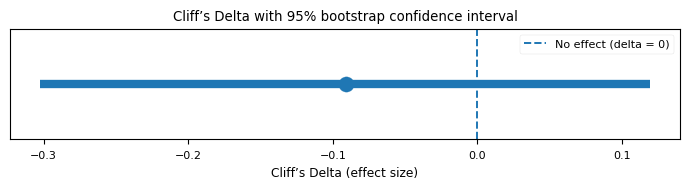

In [284]:
fig, ax = plt.subplots(figsize=(7, 2))

ax.hlines(y=0, xmin=ci_low, xmax=ci_high, linewidth=6)
ax.scatter(delta, 0, s=120, zorder=3)
ax.axvline(0, linestyle="--", label="No effect (delta = 0)")

ax.set_yticks([])
ax.set_xlabel("Cliff’s Delta (effect size)")
ax.set_title("Cliff’s Delta with 95% bootstrap confidence interval")
ax.legend()
plt.tight_layout()
plt.show()


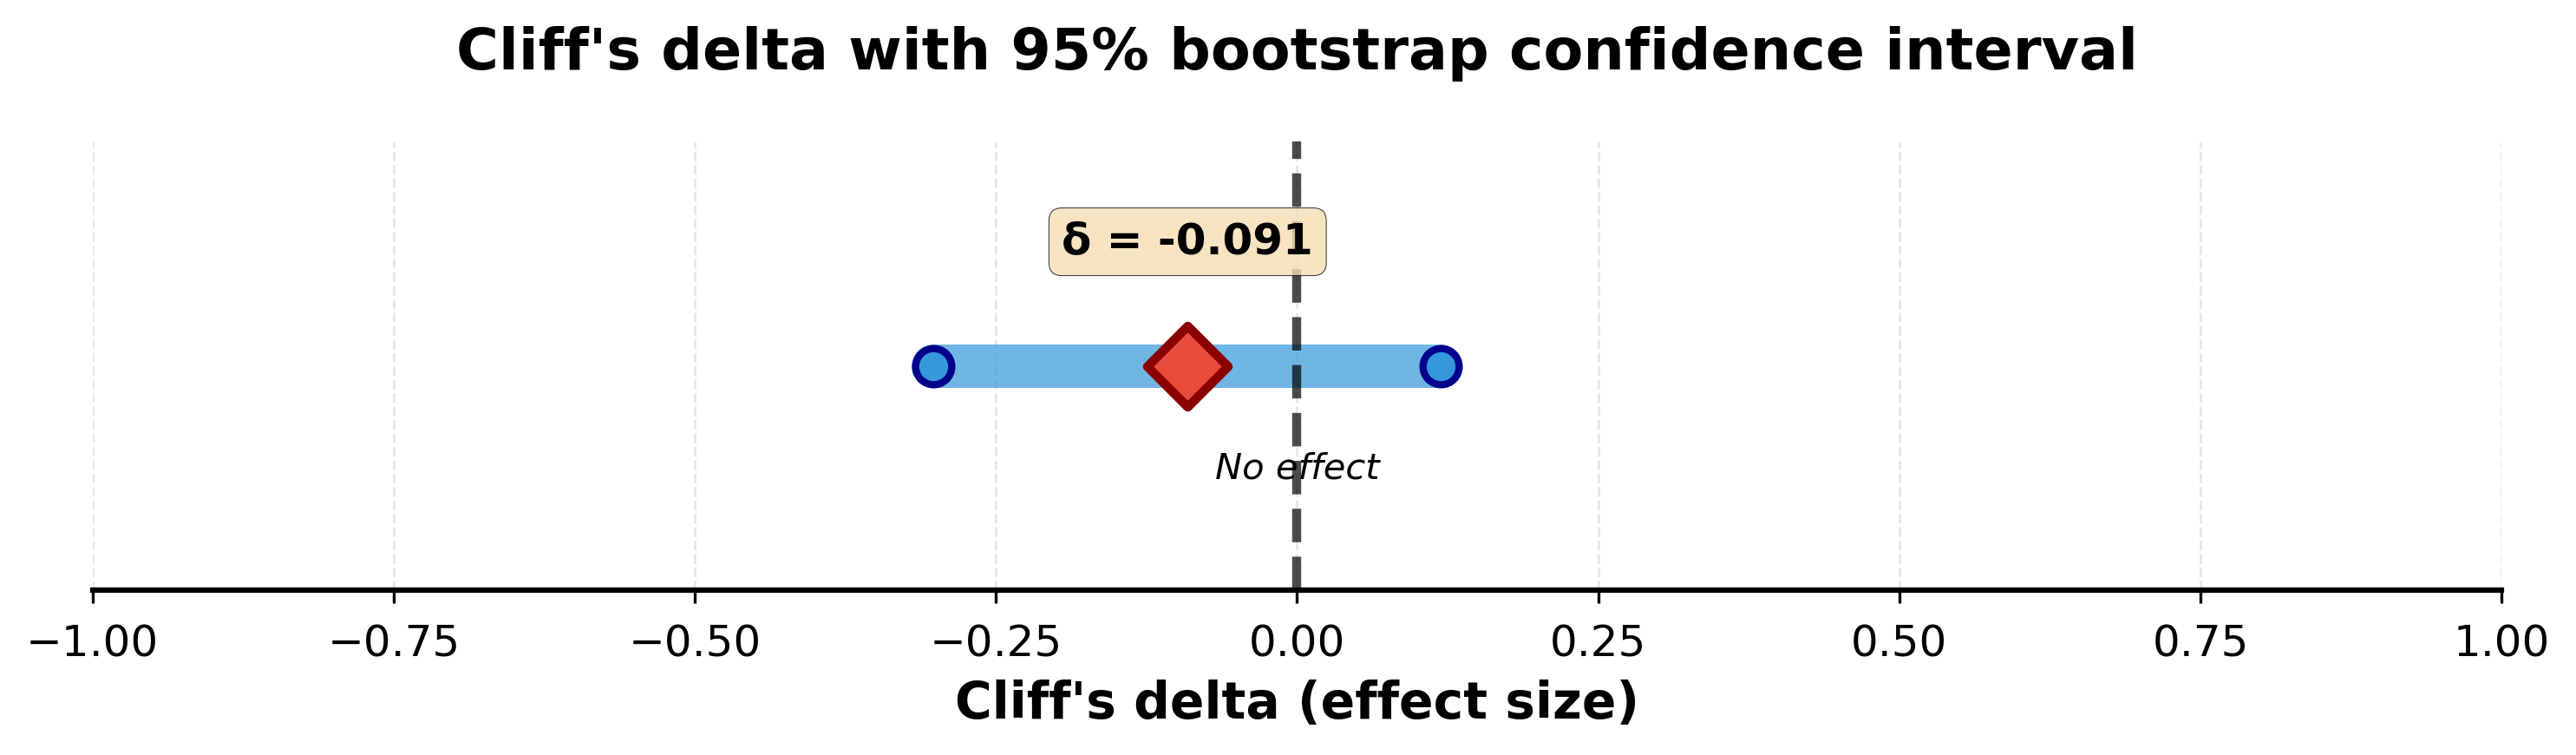

In [285]:
plt.style.use('seaborn-v0_8-paper')
fig, ax = plt.subplots(figsize=(10, 3), dpi=300) 

ax.hlines(
    y=0,
    xmin=ci_low,
    xmax=ci_high,
    linewidth=12,
    color='#3498db',
    alpha=0.7,
    capstyle='round'
) 

ax.scatter(
    [ci_low, ci_high],
    [0, 0],
    s=100,
    color='#3498db',
    edgecolors='darkblue',
    linewidth=2,
    zorder=3
)

ax.scatter(
    delta,
    0,
    s=250,
    color='#e74c3c',
    marker='D',
    edgecolors='darkred',
    linewidth=2.5,
    zorder=4
)

ax.axvline(0, linestyle='--', color='black', linewidth=2.5, alpha=0.7) 

ax.text(
    delta,
    0.15,
    f"δ = {delta:.3f}",
    ha='center',
    fontsize=12,
    fontweight='bold',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
)
ax.text(
    0,
    -0.15,
    "No effect",
    ha='center',
    fontsize=10,
    style='italic'
)

ax.set_yticks([])
ax.set_xlabel("Cliff's delta (effect size)", fontsize=14, fontweight='bold')
ax.set_xlim(-1, 1)
ax.set_ylim(-0.3, 0.3) 

ax.set_title(
    "Cliff's delta with 95% bootstrap confidence interval",
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)

ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='x', which='major', labelsize=12)

plt.tight_layout()
plt.savefig('cliffs_delta_ci.png', dpi=300, bbox_inches='tight')
plt.savefig('cliffs_delta_ci.pdf', bbox_inches='tight')
plt.show()


-------------------------------------------------------------------------------------------------------------------------------------------------

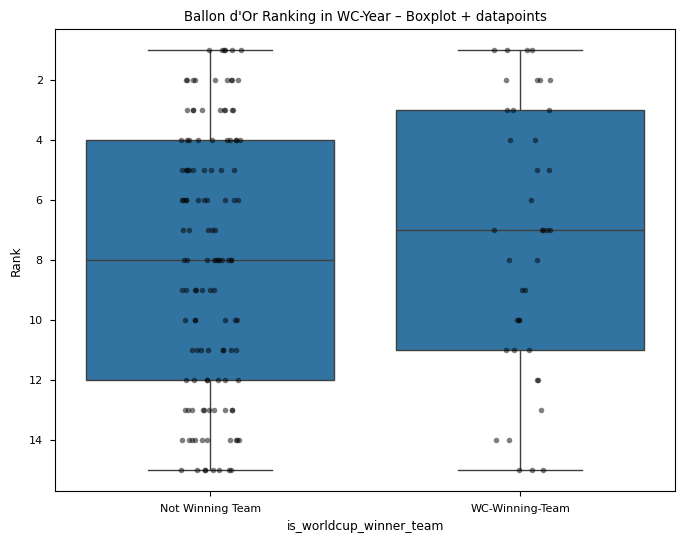

In [286]:
plt.figure(figsize=(8,6))
sns.boxplot(data=bd_ranks, x="is_worldcup_winner_team", y="Rank", showfliers=False)
sns.stripplot(data=bd_ranks, x="is_worldcup_winner_team", y="Rank", color="black", size=4, alpha=0.5)
plt.gca().invert_yaxis()
plt.xticks([0, 1], ["Not Winning Team", "WC-Winning-Team"])
plt.title("Ballon d'Or Ranking in WC-Year – Boxplot + datapoints")
plt.show()


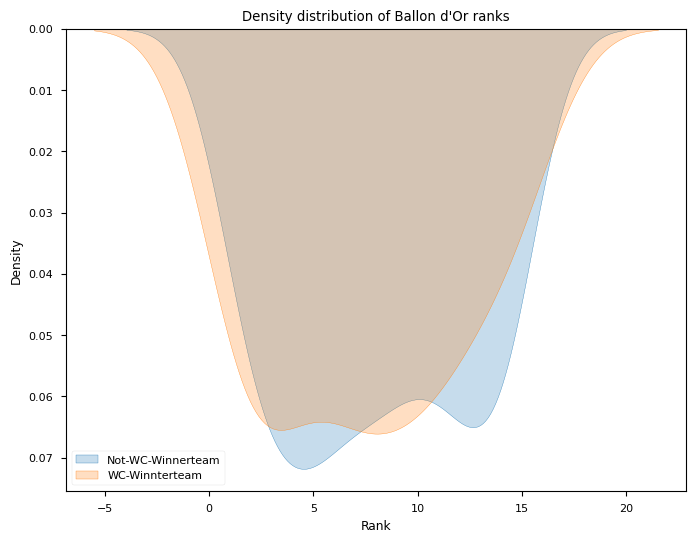

In [287]:
plt.figure(figsize=(8,6))
sns.kdeplot(data=bd_ranks[bd_ranks["is_worldcup_winner_team"] == 0]["Rank"], label="Not-WC-Winnerteam", fill=True)
sns.kdeplot(data=bd_ranks[bd_ranks["is_worldcup_winner_team"] == 1]["Rank"], label="WC-Winnterteam", fill=True)
plt.gca().invert_yaxis()
plt.title("Density distribution of Ballon d'Or ranks")
plt.legend()
plt.show()


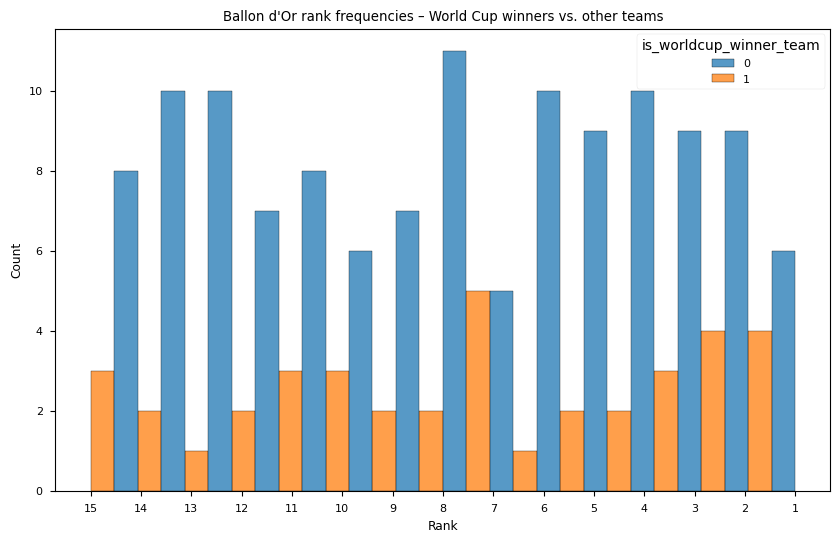

In [288]:
plt.figure(figsize=(10, 6))
sns.histplot(
    bd_ranks,
    x="Rank",
    hue="is_worldcup_winner_team",
    multiple="dodge",
    bins=15
)  
plt.gca().invert_xaxis() 
plt.title("Ballon d'Or rank frequencies – World Cup winners vs. other teams")
plt.xticks(range(1, 16))
plt.show()


-----------------------------------------------------------------------------------------------------------------------

<Center>Hypotheses 1</Center><br>

-----------------------------------------------------------------------------------------------------------------------

<li>Fischers Exact test for the Top 3 instad only looking for the Ballondor Winner</li>

In [289]:
players_bd_same["is_top3"] = (players_bd_same["Rank"] <= 3).astype(int)

In [290]:
team_top3 = (
    players_bd_same
    .groupby(["year", "team_id", "team_name"], as_index=False)
    .agg(has_top3_player=("is_top3", "any"))
    .merge(team_info[["year", "team_id", "position"]], on=["year", "team_id"])
)

team_top3["is_worldcup_winner"] = (team_top3["position"] == 1).astype(int)


In [291]:

cont_top3 = pd.crosstab(
    team_top3["is_worldcup_winner"],
    team_top3["has_top3_player"]
)

odds_top3, p_top3 = fisher_exact(cont_top3)
print(f"p-value: {p_top3}")
print(odds_top3)
print(cont_top3)


p-value: 0.11712917019150512
3.24
has_top3_player     False  True 
is_worldcup_winner              
0                      27     15
1                       5      9


c:\Users\PC\anaconda3\Lib\site-packages\statsmodels\graphics\mosaicplot.py:651: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)


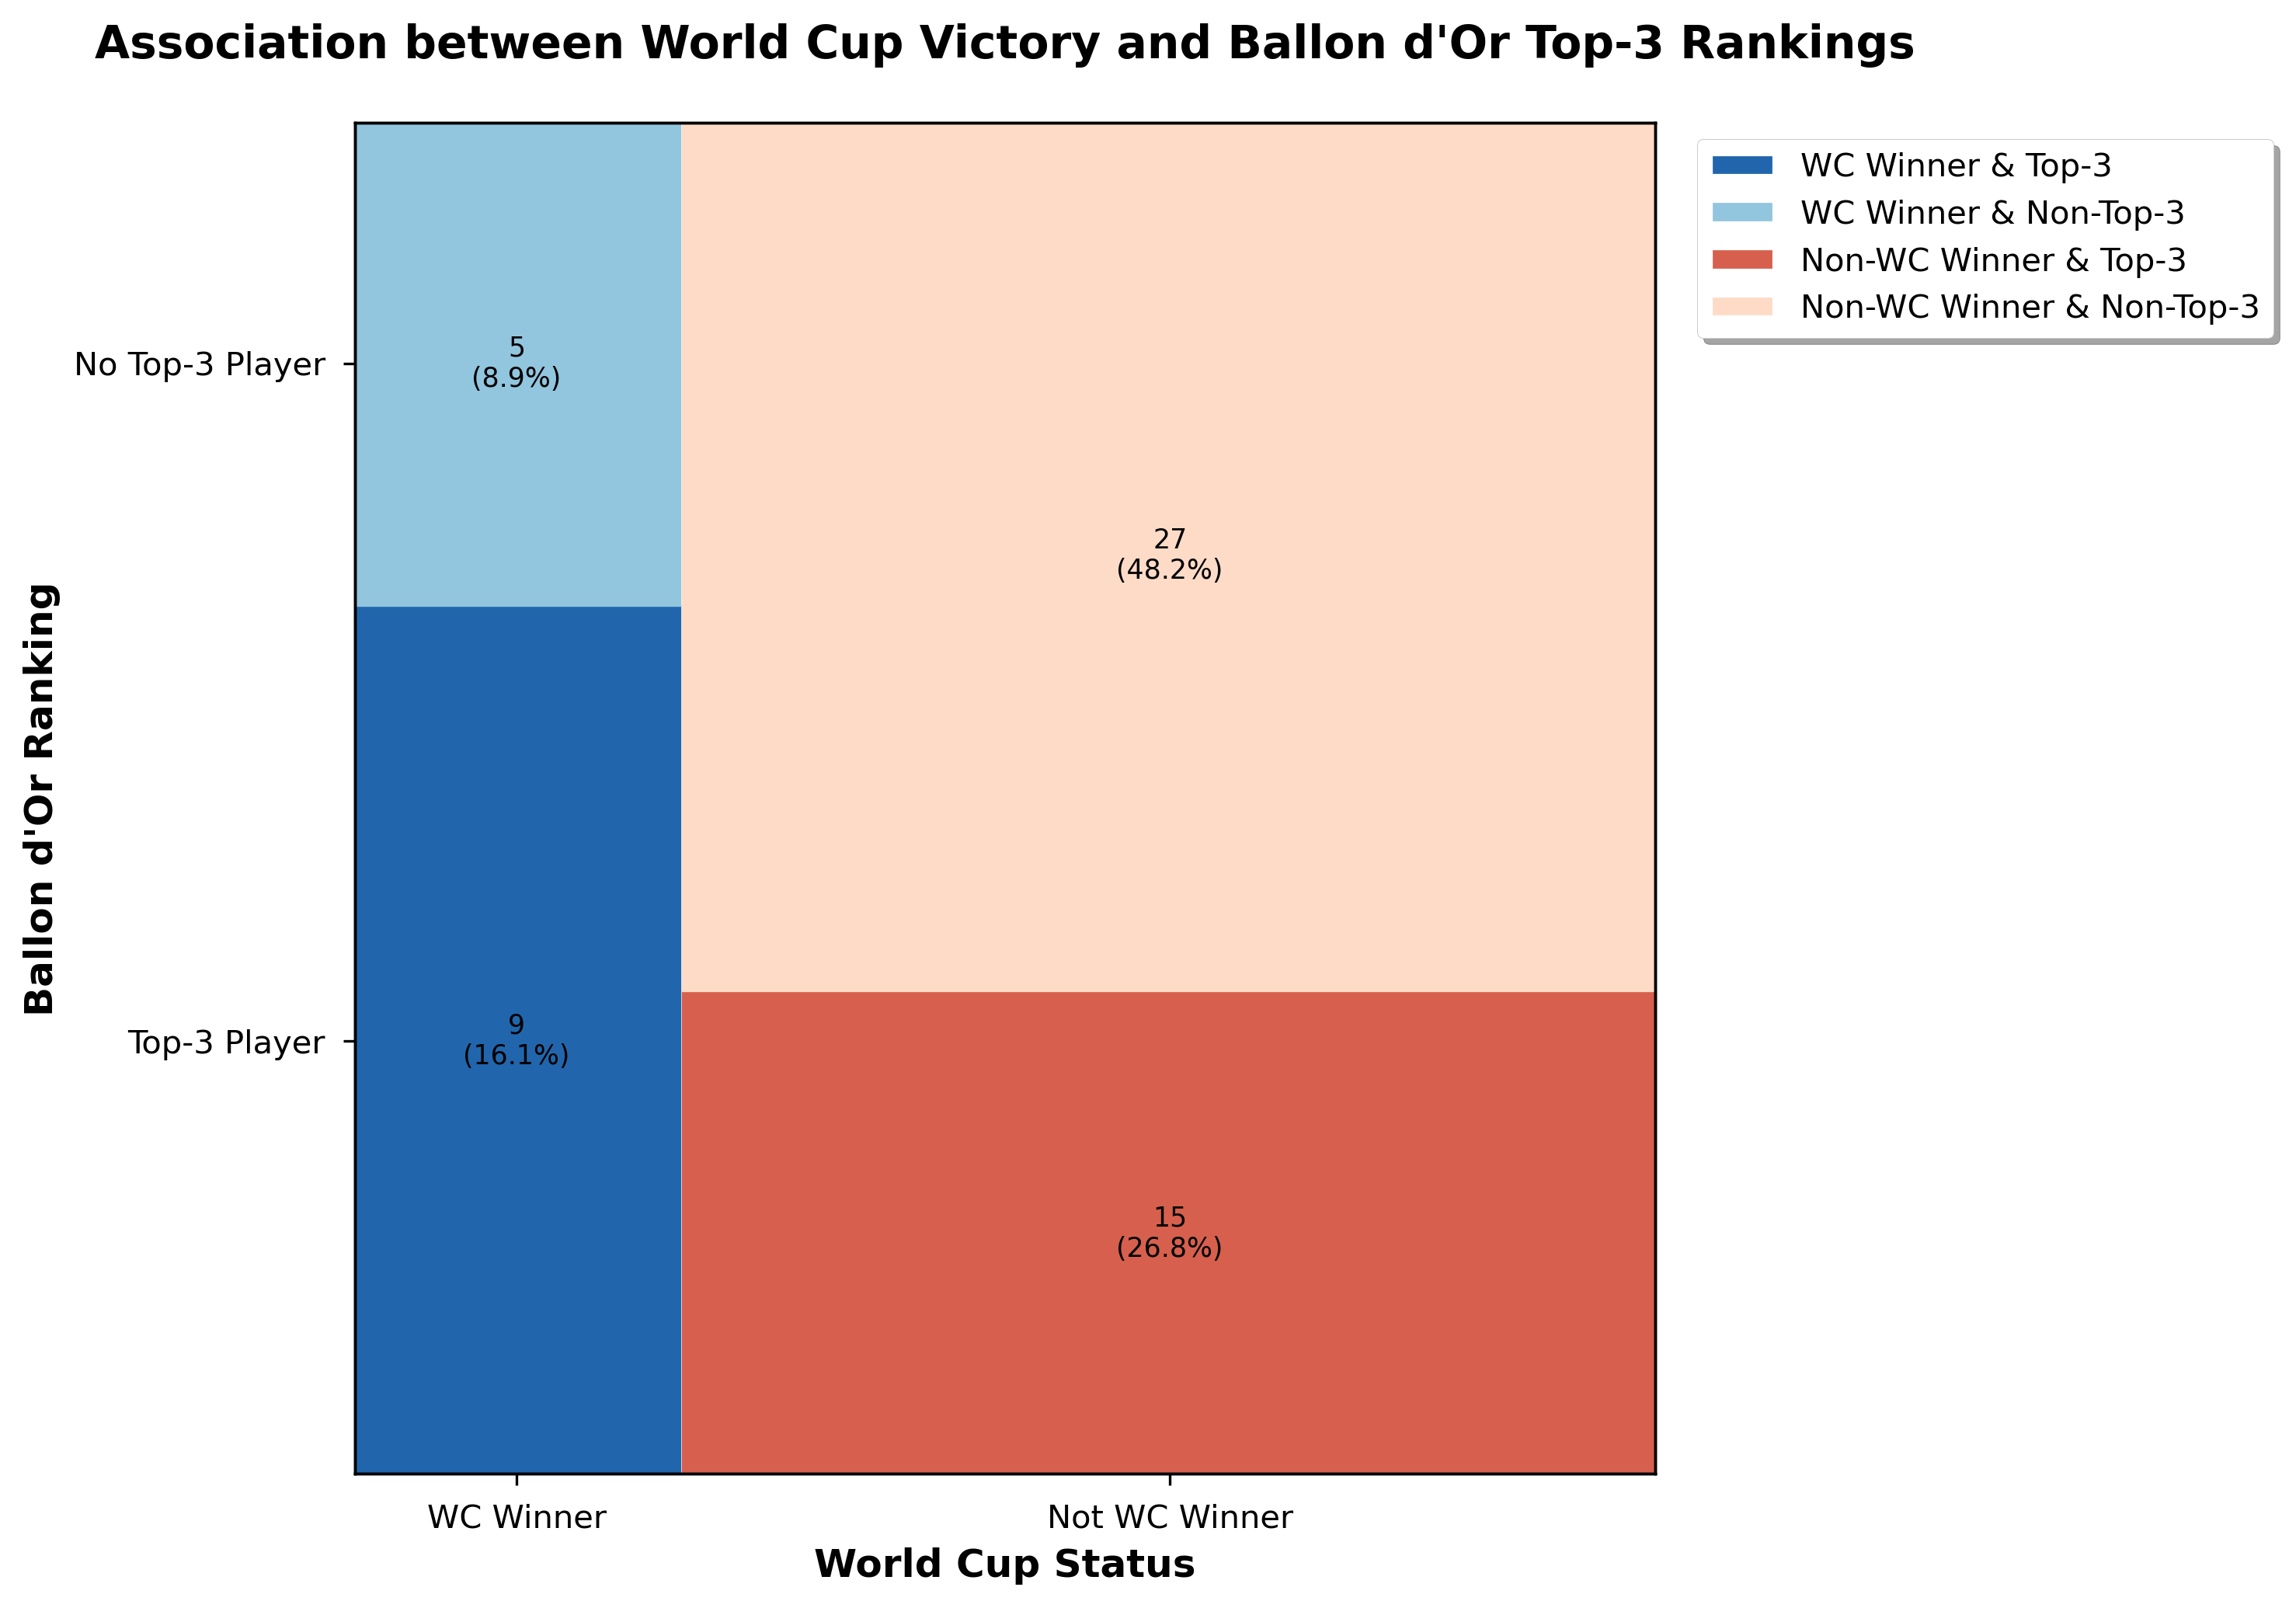

In [305]:
mosaic_data = {
    ("WC Winner", "Top-3 Player"): 9,
    ("WC Winner", "No Top-3 Player"): 5,
    ("Not WC Winner", "Top-3 Player"): 15,
    ("Not WC Winner", "No Top-3 Player"): 27,
}

colors = {
    ("WC Winner", "Top-3 Player"): '#2166ac',
    ("WC Winner", "No Top-3 Player"): '#92c5de',
    ("Not WC Winner", "Top-3 Player"): '#d6604d',
    ("Not WC Winner", "No Top-3 Player"): '#fddbc7'
}

fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

mosaic(mosaic_data, 
       ax=ax,
       properties=lambda key: {'color': colors[key], 
                               'edgecolor': 'white',
                               'linewidth': 2},
       labelizer=lambda k: f'{mosaic_data[k]}\n({100*mosaic_data[k]/sum(mosaic_data.values()):.1f}%)',
       label_rotation=[0, 0])

ax.set_title('Association between World Cup Victory and Ballon d\'Or Top-3 Rankings',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('World Cup Status', fontsize=12, fontweight='bold')
ax.set_ylabel('Ballon d\'Or Ranking', fontsize=12, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2166ac', label='WC Winner & Top-3', edgecolor='white', linewidth=1.5),
    Patch(facecolor='#92c5de', label='WC Winner & Non-Top-3', edgecolor='white', linewidth=1.5),
    Patch(facecolor='#d6604d', label='Non-WC Winner & Top-3', edgecolor='white', linewidth=1.5),
    Patch(facecolor='#fddbc7', label='Non-WC Winner & Non-Top-3', edgecolor='white', linewidth=1.5)
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), 
          fontsize=10, frameon=True, shadow=True)

plt.tight_layout()
plt.savefig('k-3.png', dpi=300, bbox_inches='tight')
plt.show()

--------------------------------------------------------------------------------------------------------------

<center>Top 10</center>

In [293]:
players_bd_same["is_top10"] = (players_bd_same["Rank"] <= 10).astype(int)


In [294]:
team_top10 = (
    players_bd_same
    .groupby(["year", "team_id", "team_name"], as_index=False)
    .agg(has_top10_player=("is_top10", "any"))
    .merge(team_info[["year", "team_id", "position"]], on=["year", "team_id"])
)

team_top10["is_worldcup_winner"] = (team_top10["position"] == 1).astype(int)

In [295]:
cont_top10 = pd.crosstab(
    team_top10["is_worldcup_winner"],
    team_top10["has_top10_player"]
)

odds_top10, p_top10 = fisher_exact(cont_top10)
print(f"p-vlaue: {p_top10}")
print(odds_top10)
print(cont_top10)

p-vlaue: 0.7507955057389036
0.8068965517241379
has_top10_player    False  True 
is_worldcup_winner              
0                      13     29
1                       5      9


c:\Users\PC\anaconda3\Lib\site-packages\statsmodels\graphics\mosaicplot.py:651: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)


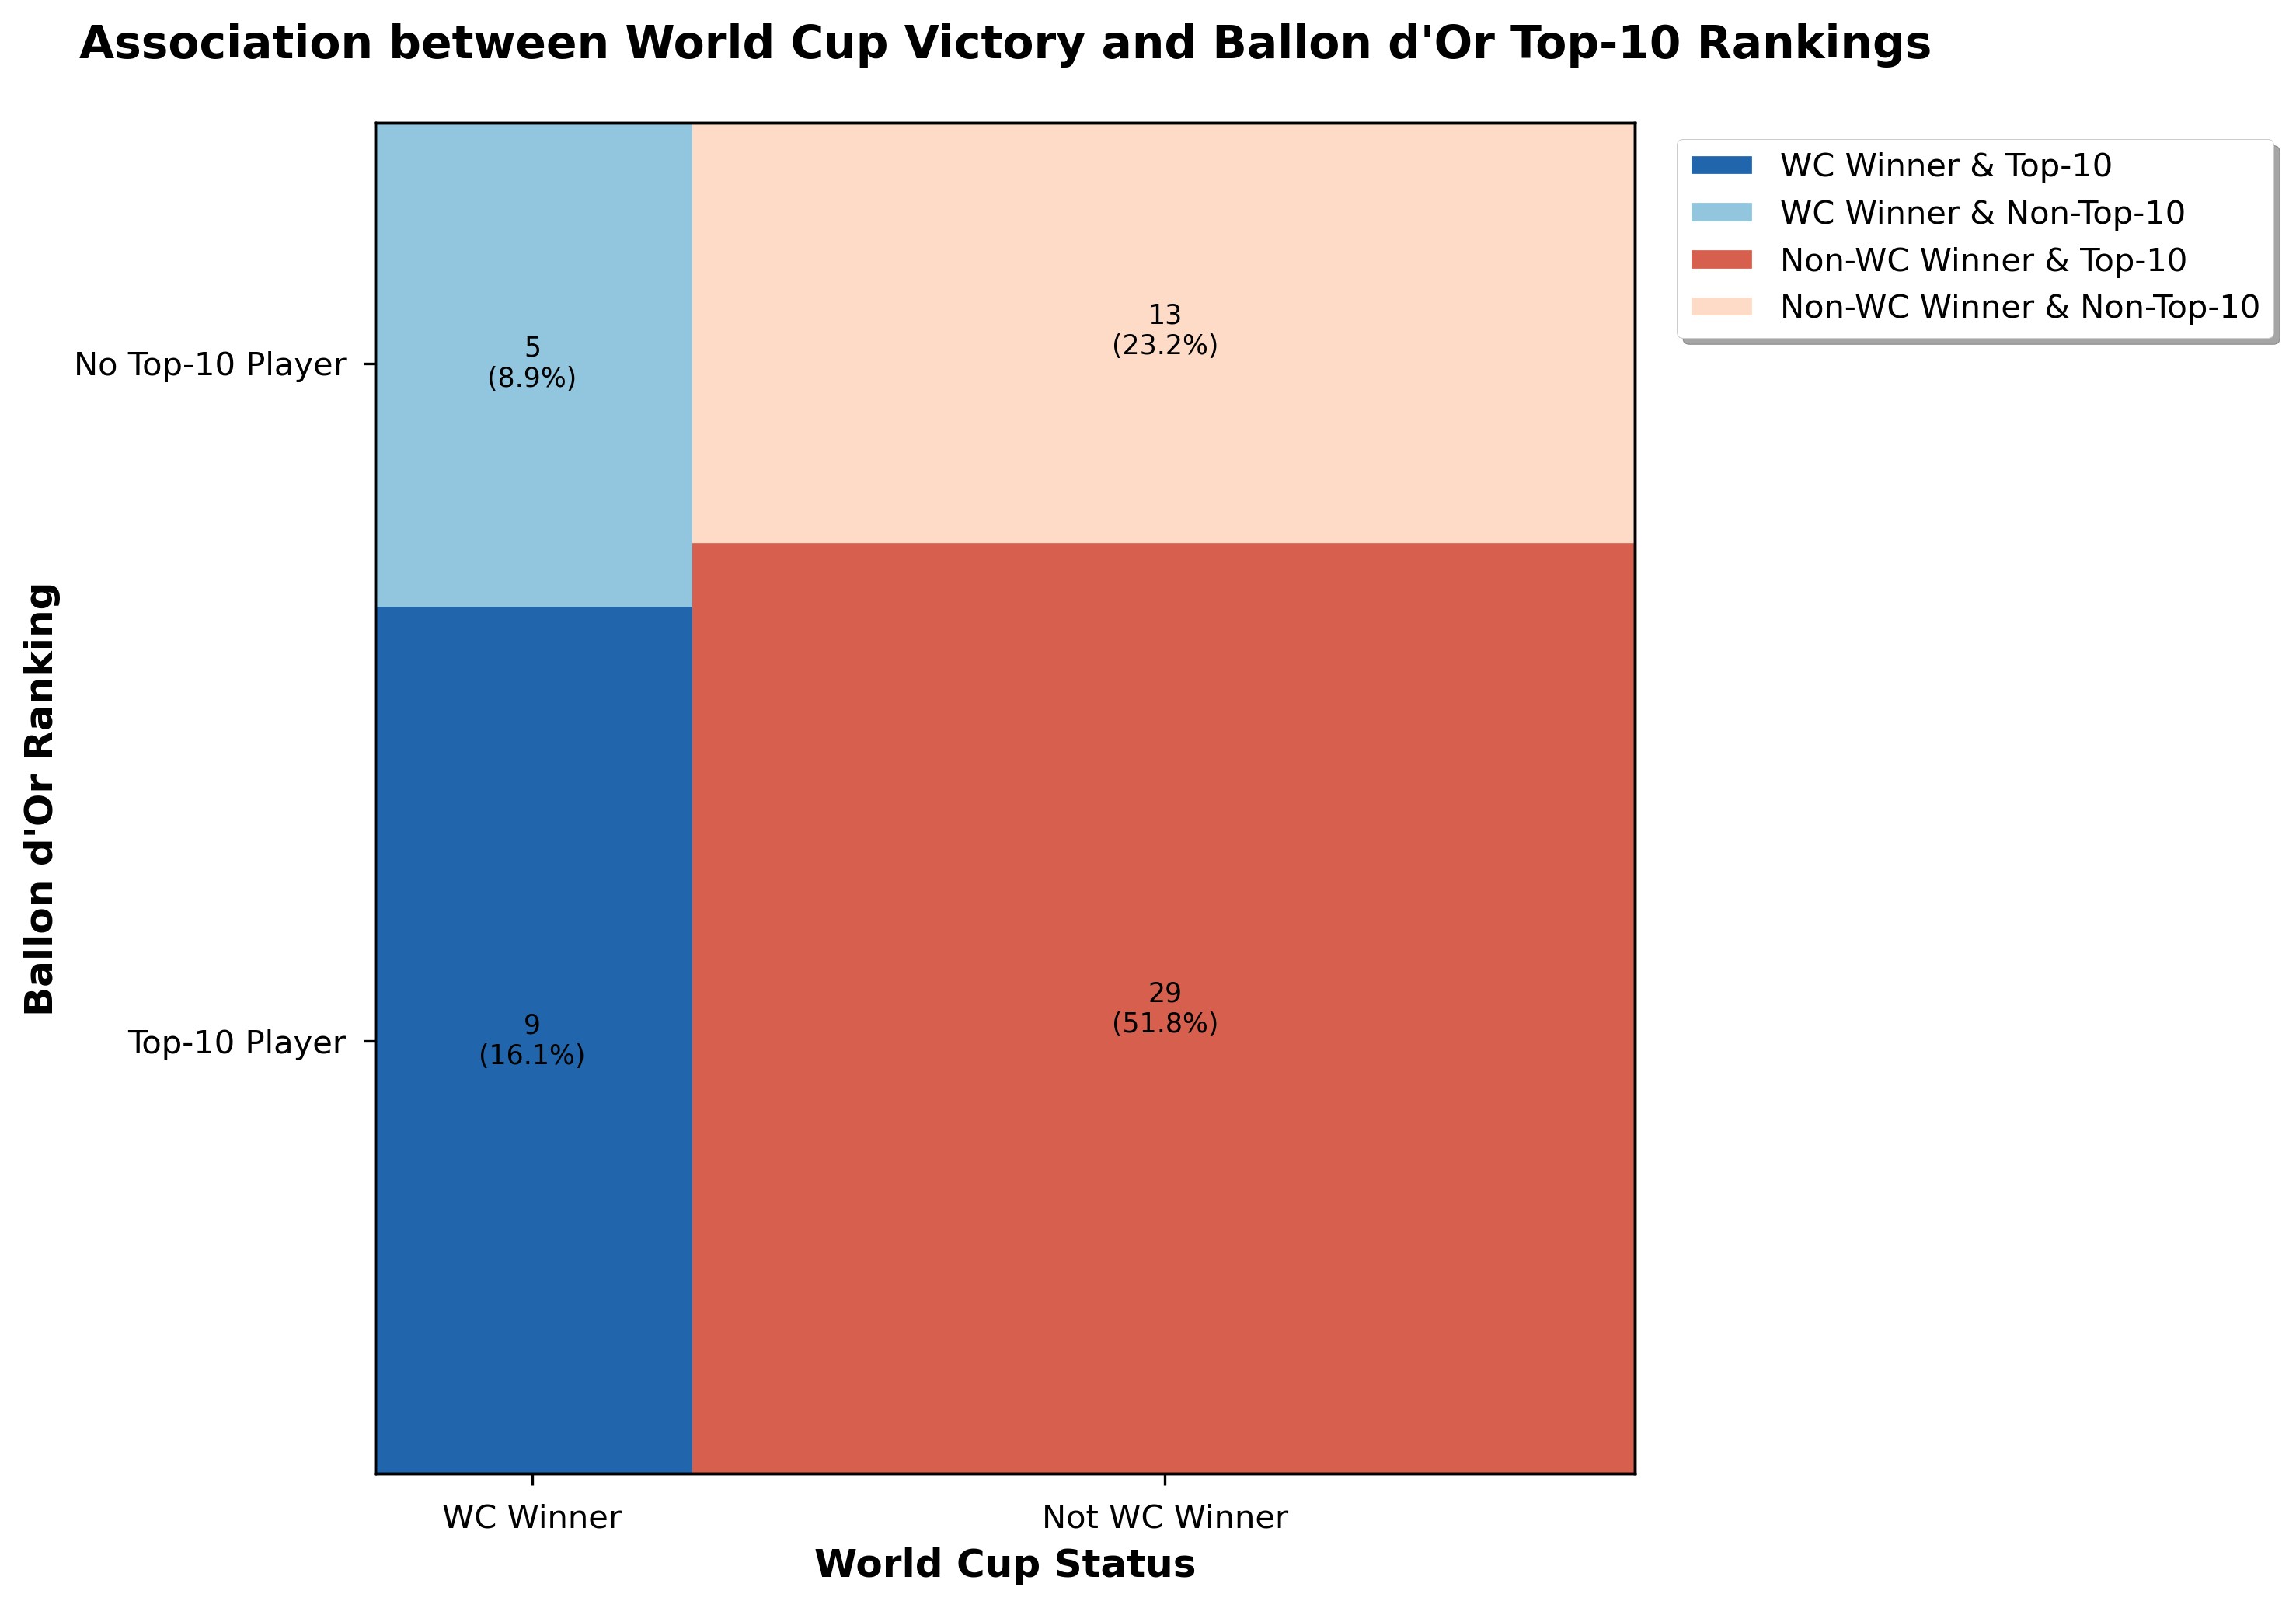

In [306]:
mosaic_data = {
    ("WC Winner", "Top-10 Player"): 9,
    ("WC Winner", "No Top-10 Player"): 5,
    ("Not WC Winner", "Top-10 Player"): 29,
    ("Not WC Winner", "No Top-10 Player"): 13,
}

colors = {
    ("WC Winner", "Top-10 Player"): '#2166ac',
    ("WC Winner", "No Top-10 Player"): '#92c5de',
    ("Not WC Winner", "Top-10 Player"): '#d6604d',
    ("Not WC Winner", "No Top-10 Player"): '#fddbc7'
}

fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

mosaic(mosaic_data, 
       ax=ax,
       properties=lambda key: {'color': colors[key], 
                               'edgecolor': 'white',
                               'linewidth': 2},
       labelizer=lambda k: f'{mosaic_data[k]}\n({100*mosaic_data[k]/sum(mosaic_data.values()):.1f}%)',
       label_rotation=[0, 0])

ax.set_title('Association between World Cup Victory and Ballon d\'Or Top-10 Rankings',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('World Cup Status', fontsize=12, fontweight='bold')
ax.set_ylabel('Ballon d\'Or Ranking', fontsize=12, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2166ac', label='WC Winner & Top-10', edgecolor='white', linewidth=1.5),
    Patch(facecolor='#92c5de', label='WC Winner & Non-Top-10', edgecolor='white', linewidth=1.5),
    Patch(facecolor='#d6604d', label='Non-WC Winner & Top-10', edgecolor='white', linewidth=1.5),
    Patch(facecolor='#fddbc7', label='Non-WC Winner & Non-Top-10', edgecolor='white', linewidth=1.5)
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), 
          fontsize=10, frameon=True, shadow=True)
          
plt.tight_layout()
plt.savefig('k-10.png', dpi=300, bbox_inches='tight')
plt.show()

--------------------------------------------------------------------------------------------------------------

<center>Top 5</center>

In [297]:
players_bd_same["is_top5"] = (players_bd_same["Rank"] <= 5).astype(int)

In [298]:
team_top5 = (
    players_bd_same
    .groupby(["year", "team_id", "team_name"], as_index=False)
    .agg(has_top5_player=("is_top5", "any"))
    .merge(team_info[["year", "team_id", "position"]], on=["year", "team_id"])
)

team_top5["is_worldcup_winner"] = (team_top5["position"] == 1).astype(int)

In [299]:
cont_top5 = pd.crosstab(
    team_top5["is_worldcup_winner"],
    team_top5["has_top5_player"]
)

odds_top5, p_top5 = fisher_exact(cont_top5)
print(f"p-vlaue: {p_top5}")
print(odds_top5)
print(cont_top5)

p-vlaue: 0.5415585221513101
1.6363636363636365
has_top5_player     False  True 
is_worldcup_winner              
0                      20     22
1                       5      9


c:\Users\PC\anaconda3\Lib\site-packages\statsmodels\graphics\mosaicplot.py:651: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)


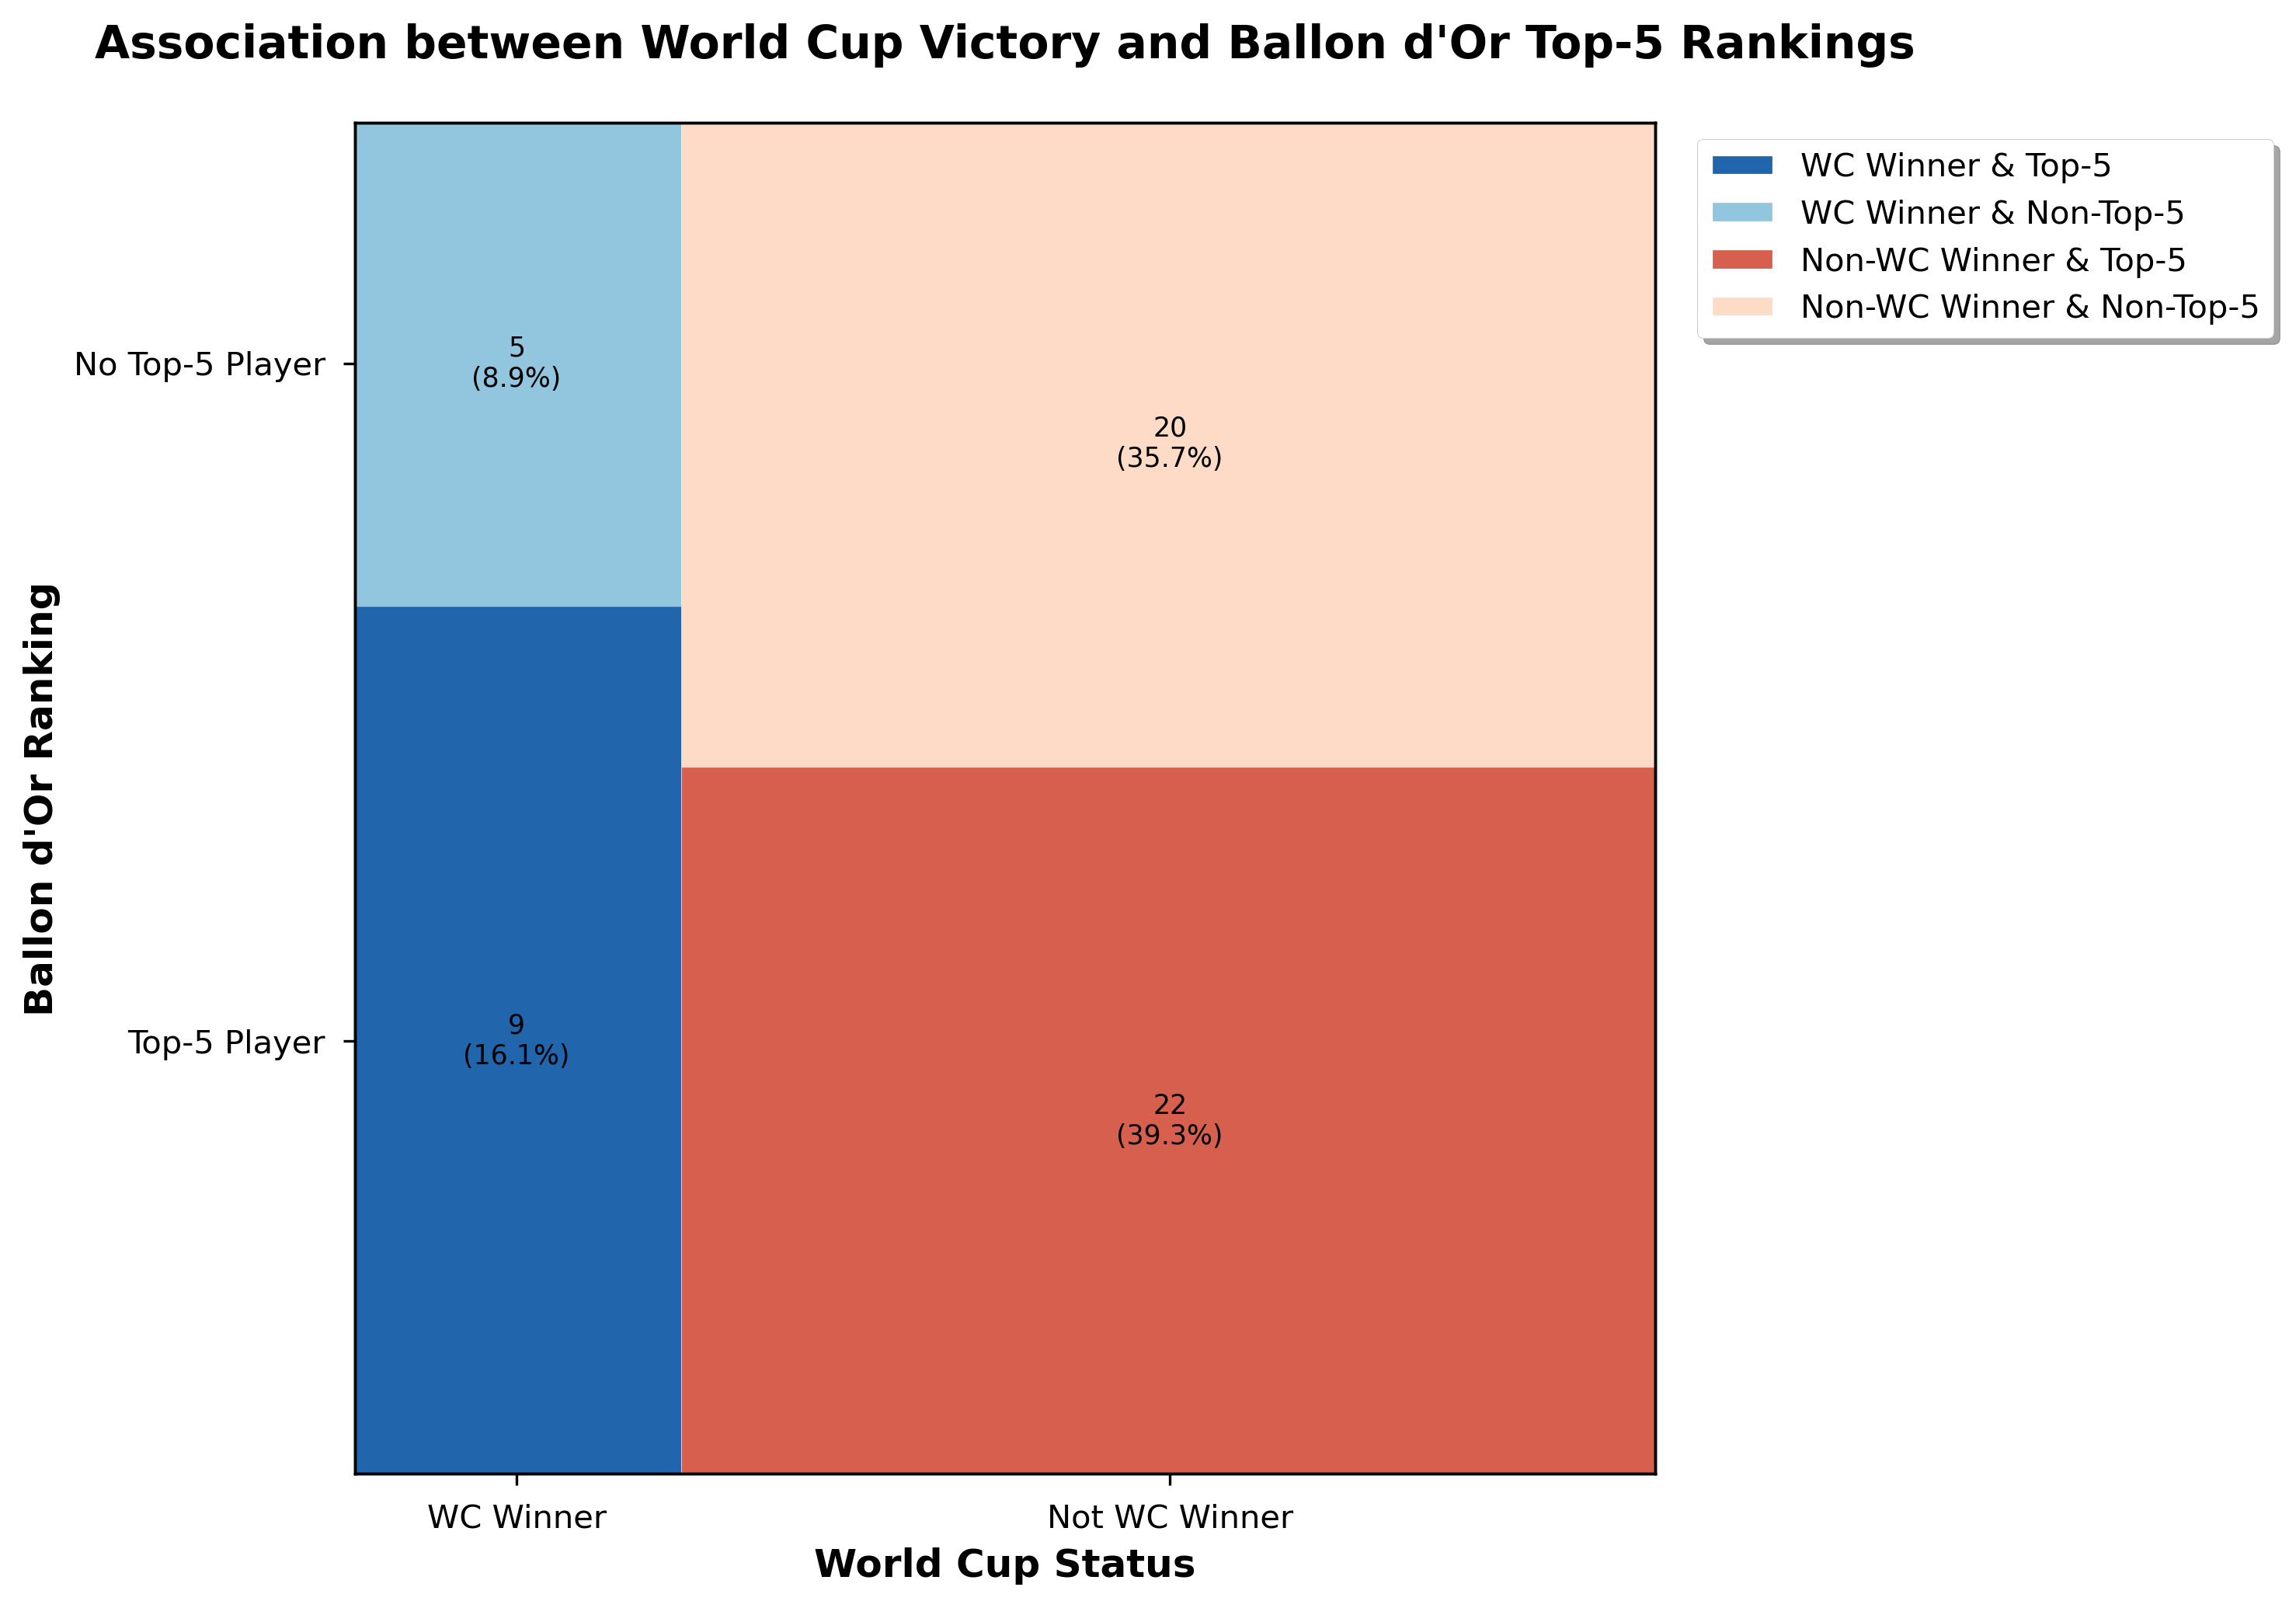

In [ ]:
mosaic_data = {
    ("WC Winner", "Top-5 Player"): 9,
    ("WC Winner", "No Top-5 Player"): 5,
    ("Not WC Winner", "Top-5 Player"): 22,
    ("Not WC Winner", "No Top-5 Player"): 20,
}

colors = {
    ("WC Winner", "Top-5 Player"): '#2166ac',
    ("WC Winner", "No Top-5 Player"): '#92c5de',
    ("Not WC Winner", "Top-5 Player"): '#d6604d',
    ("Not WC Winner", "No Top-5 Player"): '#fddbc7'
}

fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

mosaic(mosaic_data, 
       ax=ax,
       properties=lambda key: {'color': colors[key], 
                               'edgecolor': 'white',
                               'linewidth': 2},
       labelizer=lambda k: f'{mosaic_data[k]}\n({100*mosaic_data[k]/sum(mosaic_data.values()):.1f}%)',
       label_rotation=[0, 0])

ax.set_title('Association between World Cup Victory and Ballon d\'Or Top-5 Rankings',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('World Cup Status', fontsize=12, fontweight='bold')
ax.set_ylabel('Ballon d\'Or Ranking', fontsize=12, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2166ac', label='WC Winner & Top-5', edgecolor='white', linewidth=1.5),
    Patch(facecolor='#92c5de', label='WC Winner & Non-Top-5', edgecolor='white', linewidth=1.5),
    Patch(facecolor='#d6604d', label='Non-WC Winner & Top-5', edgecolor='white', linewidth=1.5),
    Patch(facecolor='#fddbc7', label='Non-WC Winner & Non-Top-5', edgecolor='white', linewidth=1.5)
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), 
          fontsize=10, frameon=True, shadow=True)
plt.tight_layout()
plt.savefig('k-5.png', dpi=300, bbox_inches='tight')
plt.show()

--------------------------------------------------------------------------------------------------------------

<center>Top 15</center>

In [301]:
players_bd_same["is_top15"] = (players_bd_same["Rank"] <= 15).astype(int)

In [302]:
team_top15 = (
    players_bd_same
    .groupby(["year", "team_id", "team_name"], as_index=False)
    .agg(has_top15_player=("is_top15", "any"))
    .merge(team_info[["year", "team_id", "position"]], on=["year", "team_id"])
)

team_top15["is_worldcup_winner"] = (team_top15["position"] == 1).astype(int)

In [303]:
cont_top15 = pd.crosstab(
    team_top15["is_worldcup_winner"],
    team_top15["has_top15_player"]
)

odds_top15, p_top15 = fisher_exact(cont_top15)
print(f"p-value: {p_top15}")
print(odds_top15)
print(cont_top15)

p-value: 0.3044765169480779
0.4909090909090909
has_top15_player    False  True 
is_worldcup_winner              
0                       9     33
1                       5      9


c:\Users\PC\anaconda3\Lib\site-packages\statsmodels\graphics\mosaicplot.py:651: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)


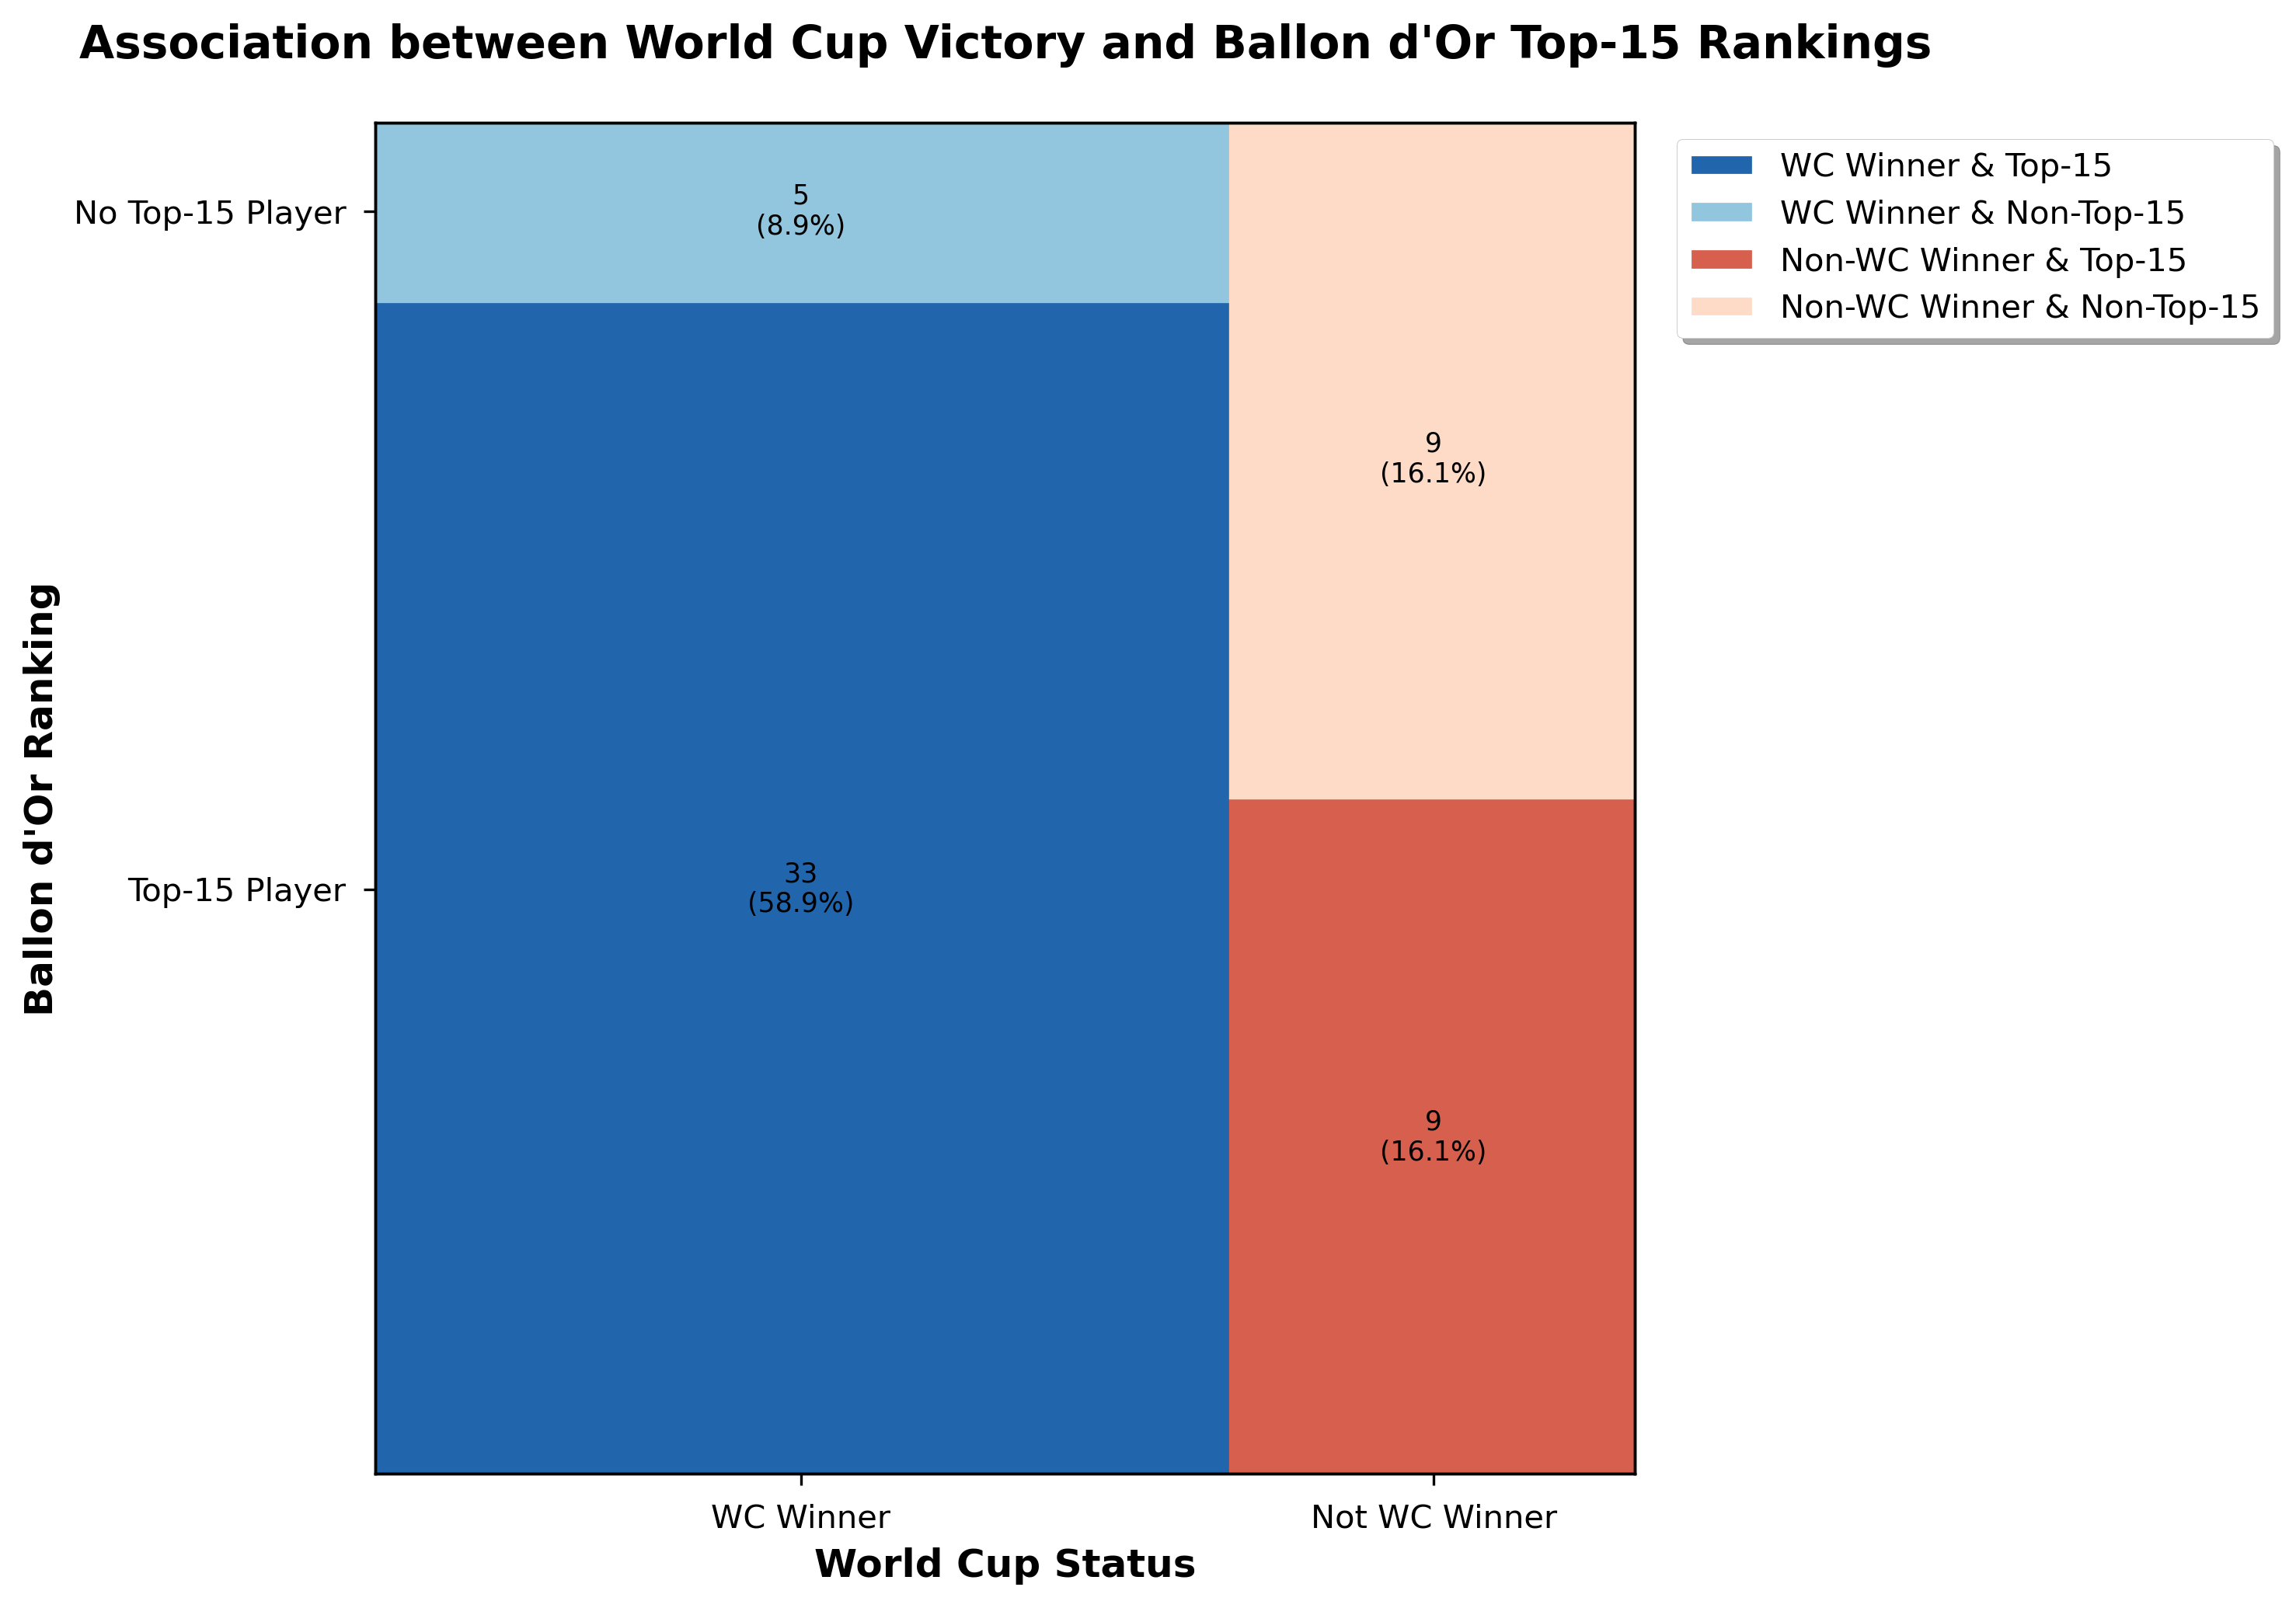

In [304]:
mosaic_data = {
    ("WC Winner", "Top-15 Player"): 33,
    ("WC Winner", "No Top-15 Player"): 5,
    ("Not WC Winner", "Top-15 Player"): 9,
    ("Not WC Winner", "No Top-15 Player"): 9,
}

colors = {
    ("WC Winner", "Top-15 Player"): '#2166ac',
    ("WC Winner", "No Top-15 Player"): '#92c5de',
    ("Not WC Winner", "Top-15 Player"): '#d6604d',
    ("Not WC Winner", "No Top-15 Player"): '#fddbc7'
}

fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

mosaic(mosaic_data, 
       ax=ax,
       properties=lambda key: {'color': colors[key], 
                               'edgecolor': 'white',
                               'linewidth': 2},
       labelizer=lambda k: f'{mosaic_data[k]}\n({100*mosaic_data[k]/sum(mosaic_data.values()):.1f}%)',
       label_rotation=[0, 0])

ax.set_title('Association between World Cup Victory and Ballon d\'Or Top-15 Rankings',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('World Cup Status', fontsize=12, fontweight='bold')
ax.set_ylabel('Ballon d\'Or Ranking', fontsize=12, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2166ac', label='WC Winner & Top-15', edgecolor='white', linewidth=1.5),
    Patch(facecolor='#92c5de', label='WC Winner & Non-Top-15', edgecolor='white', linewidth=1.5),
    Patch(facecolor='#d6604d', label='Non-WC Winner & Top-15', edgecolor='white', linewidth=1.5),
    Patch(facecolor='#fddbc7', label='Non-WC Winner & Non-Top-15', edgecolor='white', linewidth=1.5)
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), 
          fontsize=10, frameon=True, shadow=True)

plt.tight_layout()
plt.show()